In [1783]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from turtle import color
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

# **| Trabajo sobre Grecia**

In [1784]:
resultados = {}

In [1785]:
#Cargar desde un archivo .csv
Grecia = pd.read_csv('Grecia.csv')

#Eliminar columnas inecesarias
df = Grecia.drop(['Unnamed: 0'], axis=1)
df.head()


,last_scraped,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,2024-09-23,city scrape,"3 bedrooms, 2 bathrooms, 2nd floor with elevator",The apartment is 3-bedroom apartment with 2-ba...,Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,340,53.0,0.0,4.87,4.89,4.85,4.91,4.58,4.75,0.33
1,2024-09-23,city scrape,Athens Quality Apartments - Deluxe Apartment,Athens Quality Apartments - Deluxe apartment i...,Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,350,82.0,0.0,4.83,4.85,4.85,4.90,4.80,4.75,0.56
2,2024-09-23,city scrape,Athens Quality Apartments - Studio,The Studio is an <br />-excellent located <br ...,Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,341,107.0,0.0,4.85,4.92,4.93,4.97,4.79,4.78,0.73
3,2024-09-23,city scrape,"AQA-No2 1-bedroom, smart tv, fiber connection,","AQA No2 is 1-bedroom apartment (47m2), on the ...",Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,350,36.0,0.0,4.83,4.97,4.91,4.89,4.82,4.82,0.21
4,2024-09-23,city scrape,"AQA-No7, Great mattress, high speed internet",THE MATTRESS - KING KOIL - Camden Luxury 160x2...,No disponible,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,358,25.0,0.0,4.84,4.88,4.96,4.96,4.75,4.71,0.17


In [1786]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14137 entries, 0 to 14136
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   last_scraped                 14137 non-null  object 
 1   source                       14137 non-null  object 
 2   name                         14137 non-null  object 
 3   description                  14137 non-null  object 
 4   neighborhood_overview        14137 non-null  object 
 5   host_name                    14137 non-null  object 
 6   host_since                   14137 non-null  object 
 7   host_location                14137 non-null  object 
 8   host_about                   14137 non-null  object 
 9   host_response_time           14137 non-null  object 
 10  host_is_superhost            14137 non-null  object 
 11  host_verifications           14137 non-null  object 
 12  host_identity_verified       14137 non-null  object 
 13  neighbourhood_cl

In [1787]:
# Convertir 'host_is_superhost' a numérico
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

In [1788]:
# Convertir 'room_type' en variables dummy
df['room_type'] = df['room_type'].astype('category').cat.codes

In [1789]:
variables = [
    ("id"),
    ("host_acceptance_rate"),
    ("host_is_superhost"),
    ("host_total_listings_count"),
    ("room_type"),
    ("accommodates"),
    ("bedrooms"),
    ("price"),
    ("review_scores_value"),
    ("reviews_per_month")
]

In [1790]:
#eliminamos la columna tipo string
df = df.select_dtypes(include=[np.number])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14137 entries, 0 to 14136
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            14137 non-null  int64  
 1   room_type                    14137 non-null  int8   
 2   id                           14137 non-null  int64  
 3   host_response_rate           14137 non-null  float64
 4   host_acceptance_rate         14137 non-null  float64
 5   host_listings_count          14137 non-null  float64
 6   host_total_listings_count    14137 non-null  float64
 7   latitude                     14137 non-null  float64
 8   longitude                    14137 non-null  float64
 9   accommodates                 14137 non-null  float64
 10  bathrooms                    14137 non-null  float64
 11  bedrooms                     14137 non-null  float64
 12  beds                         14137 non-null  float64
 13  price           

In [1791]:
#Encontramos todas las correlaciones entre las variables
corr_Factors = df.corr()
corr_Factors

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
host_is_superhost,1.000000,-0.130936,-0.088233,0.081040,0.091611,-0.112243,-0.104036,-0.083299,-0.056355,0.068492,...,0.011217,0.212551,0.245506,0.237263,0.206672,0.226731,0.148628,0.108240,0.205541,0.261953
room_type,-0.130936,1.000000,-0.010055,-0.090046,-0.140941,-0.032380,0.006350,0.081783,-0.024948,-0.248443,...,-0.015561,-0.100721,-0.114916,-0.042178,-0.039894,-0.061990,-0.013442,-0.027344,-0.037120,-0.149157
id,-0.088233,-0.010055,1.000000,-0.041893,0.000265,0.035090,0.043186,0.047703,0.015082,-0.042532,...,0.003219,-0.500516,-0.053714,0.046751,0.025537,0.048247,0.012924,-0.042258,0.019577,-0.045321
host_response_rate,0.081040,-0.090046,-0.041893,1.000000,0.109590,0.003276,-0.019326,-0.017198,-0.039117,0.029407,...,0.014377,0.073665,0.085754,0.078609,0.070646,0.079460,0.098604,0.037042,0.074535,0.087398
host_acceptance_rate,0.091611,-0.140941,0.000265,0.109590,1.000000,0.088277,0.083391,-0.080578,-0.052100,0.065168,...,0.023986,0.103699,0.120801,0.002922,0.004849,0.038703,0.006224,0.008501,0.006295,0.145074
host_listings_count,-0.112243,-0.032380,0.035090,0.003276,0.088277,1.000000,0.874521,-0.073206,-0.023474,0.041205,...,0.098315,-0.034778,-0.017782,-0.128799,-0.099656,-0.094654,-0.137650,-0.043467,-0.130659,-0.019807
host_total_listings_count,-0.104036,0.006350,0.043186,-0.019326,0.083391,0.874521,1.000000,-0.076136,-0.026691,0.015749,...,0.053100,-0.020386,-0.009045,-0.113795,-0.089490,-0.085121,-0.118124,-0.033399,-0.115572,-0.003855
latitude,-0.083299,0.081783,0.047703,-0.017198,-0.080578,-0.073206,-0.076136,1.000000,0.142193,-0.104043,...,-0.063249,-0.105307,-0.107372,-0.072257,-0.062473,-0.068612,-0.035138,-0.329708,-0.074387,-0.129177
longitude,-0.056355,-0.024948,0.015082,-0.039117,-0.052100,-0.023474,-0.026691,0.142193,1.000000,-0.032432,...,-0.012409,-0.086500,-0.091912,0.007696,-0.007424,-0.017425,-0.015021,0.088987,-0.028160,-0.108753
accommodates,0.068492,-0.248443,-0.042532,0.029407,0.065168,0.041205,0.015749,-0.104043,-0.032432,1.000000,...,0.024389,0.057936,0.004160,0.074714,0.058421,0.061578,0.029197,0.051945,0.089535,0.036524


In [1792]:
corr_Factors1 = abs(corr_Factors)
corr_Factors1

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
host_is_superhost,1.000000,0.130936,0.088233,0.081040,0.091611,0.112243,0.104036,0.083299,0.056355,0.068492,...,0.011217,0.212551,0.245506,0.237263,0.206672,0.226731,0.148628,0.108240,0.205541,0.261953
room_type,0.130936,1.000000,0.010055,0.090046,0.140941,0.032380,0.006350,0.081783,0.024948,0.248443,...,0.015561,0.100721,0.114916,0.042178,0.039894,0.061990,0.013442,0.027344,0.037120,0.149157
id,0.088233,0.010055,1.000000,0.041893,0.000265,0.035090,0.043186,0.047703,0.015082,0.042532,...,0.003219,0.500516,0.053714,0.046751,0.025537,0.048247,0.012924,0.042258,0.019577,0.045321
host_response_rate,0.081040,0.090046,0.041893,1.000000,0.109590,0.003276,0.019326,0.017198,0.039117,0.029407,...,0.014377,0.073665,0.085754,0.078609,0.070646,0.079460,0.098604,0.037042,0.074535,0.087398
host_acceptance_rate,0.091611,0.140941,0.000265,0.109590,1.000000,0.088277,0.083391,0.080578,0.052100,0.065168,...,0.023986,0.103699,0.120801,0.002922,0.004849,0.038703,0.006224,0.008501,0.006295,0.145074
host_listings_count,0.112243,0.032380,0.035090,0.003276,0.088277,1.000000,0.874521,0.073206,0.023474,0.041205,...,0.098315,0.034778,0.017782,0.128799,0.099656,0.094654,0.137650,0.043467,0.130659,0.019807
host_total_listings_count,0.104036,0.006350,0.043186,0.019326,0.083391,0.874521,1.000000,0.076136,0.026691,0.015749,...,0.053100,0.020386,0.009045,0.113795,0.089490,0.085121,0.118124,0.033399,0.115572,0.003855
latitude,0.083299,0.081783,0.047703,0.017198,0.080578,0.073206,0.076136,1.000000,0.142193,0.104043,...,0.063249,0.105307,0.107372,0.072257,0.062473,0.068612,0.035138,0.329708,0.074387,0.129177
longitude,0.056355,0.024948,0.015082,0.039117,0.052100,0.023474,0.026691,0.142193,1.000000,0.032432,...,0.012409,0.086500,0.091912,0.007696,0.007424,0.017425,0.015021,0.088987,0.028160,0.108753
accommodates,0.068492,0.248443,0.042532,0.029407,0.065168,0.041205,0.015749,0.104043,0.032432,1.000000,...,0.024389,0.057936,0.004160,0.074714,0.058421,0.061578,0.029197,0.051945,0.089535,0.036524


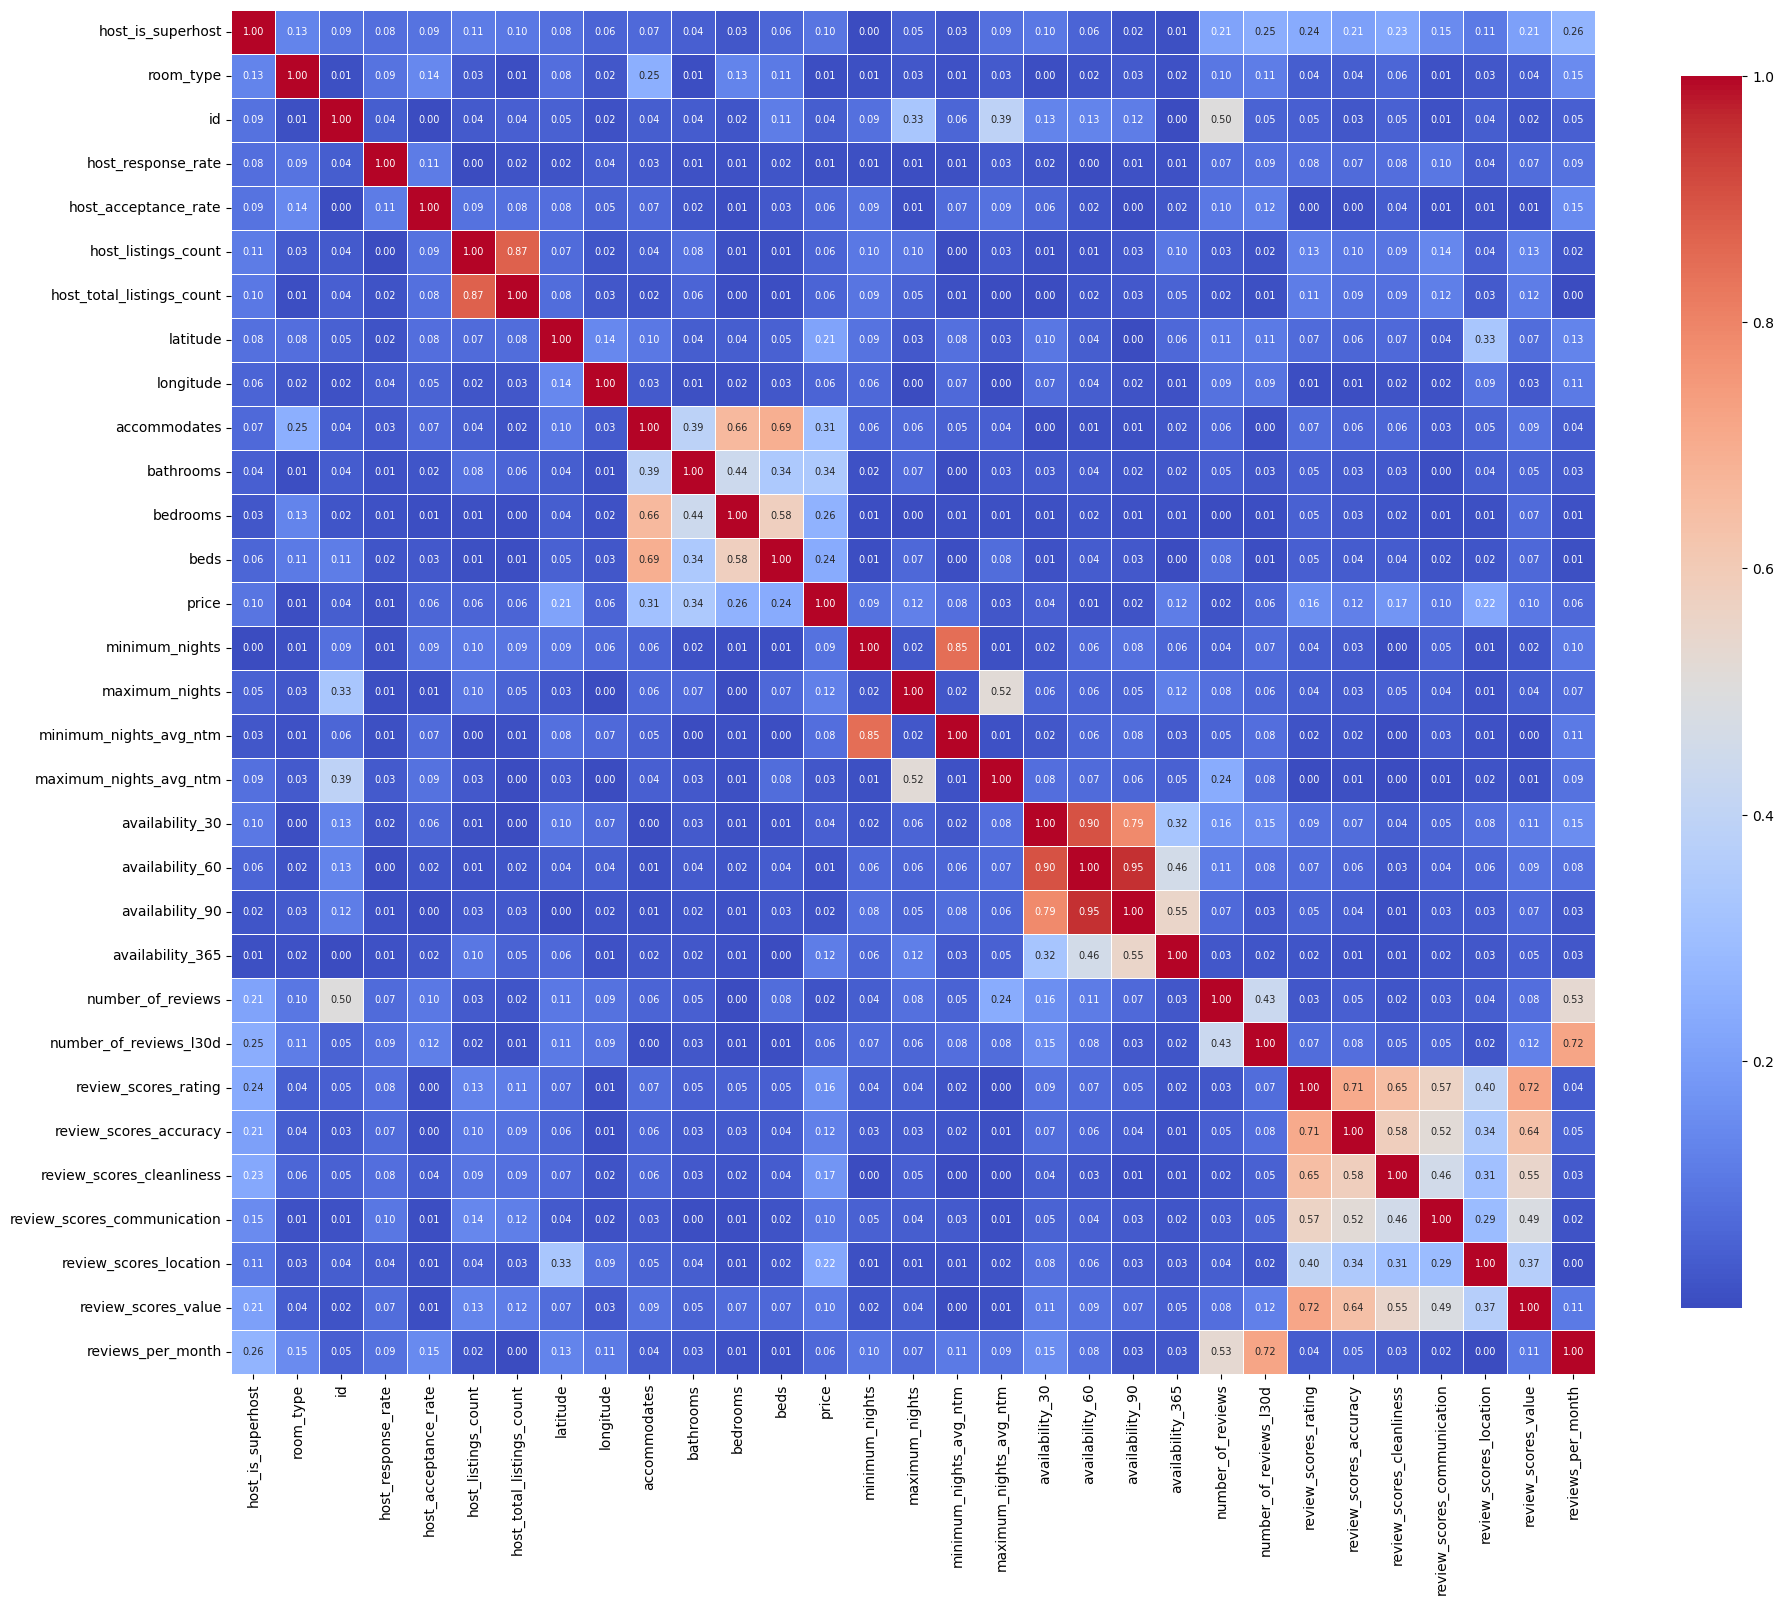

In [1793]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(22, 20))

# Crear una máscara para la mitad superior (opcional, si quieres ver solo la parte baja)
mask = np.triu(np.ones_like(corr_Factors1, dtype=bool))

# Crear el mapa de calor con mejoras
heat_map = sns.heatmap(
    corr_Factors1, 
    cmap="coolwarm",   # Mejora la diferenciación entre positivos y negativos
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    square=True,       
    annot_kws={"size": 7},  # Reducimos el tamaño de los números internos
    cbar_kws={"shrink": 0.8}  # Hacemos la barra de colores más compacta
)

# Mejoramos la visibilidad de etiquetas
plt.xticks(rotation=90)  # Rota nombres en X para que no se encimen
plt.yticks(rotation=0)   # Mantiene etiquetas en Y horizontales

# Mostrar el gráfico
plt.show()


In [1794]:
mejores_variables = {}

for var in variables:
    # Obtener las correlaciones de la variable actual con las demás, excluyéndose a sí misma
    corr_var = corr_Factors1[var].drop(var).sort_values(ascending=False)
    
    # Filtrar solo las variables que están en la lista de variables de interés
    filtered_vars = [(v, corr_var[v]) for v in corr_var.index]
    
    # Tomar las tres variables con mayor correlación
    mejores_variables[var] = filtered_vars[:3]

# Convertir el diccionario en una lista de filas para el DataFrame
tabla_corr = []

for var, correlaciones in mejores_variables.items():
    for i, (var_correlacionada, valor_corr) in enumerate(correlaciones, start=1):
        tabla_corr.append([var, f"Var_{i}", var_correlacionada, valor_corr])

# Crear el DataFrame con columnas organizadas
df_corr = pd.DataFrame(tabla_corr, columns=["Variable", "Ranking", "Variable Correlacionada", "Valor Correlación"])

# Formatear la salida para mejor visualización
df_corr = df_corr.pivot(index="Variable", columns="Ranking", values=["Variable Correlacionada", "Valor Correlación"])

# Ordenar las variables para mayor claridad
df_corr = df_corr.sort_index()

# Mostrar la tabla
df_corr



Variable Correlacionada  \
Ranking                                     Var_1   
Variable                                            
accommodates                                 beds   
bedrooms                             accommodates   
host_acceptance_rate            reviews_per_month   
host_is_superhost               reviews_per_month   
host_total_listings_count     host_listings_count   
id                              number_of_reviews   
price                                   bathrooms   
review_scores_value          review_scores_rating   
reviews_per_month          number_of_reviews_l30d   
room_type                            accommodates   

                                                        \
Ranking                                          Var_2   
Variable                                                 
accommodates                                  bedrooms   
bedrooms                                          beds   
host_acceptance_rate                         room_type   
host_is_superhost               number_of_reviews_l30d   
host_total_listings_count  review_scores_communication   
id                              maximum_nights_avg_ntm   
price                                     accommodates   
review_scores_value             review_scores_accuracy   
reviews_per_month                    number_of_reviews   
room_type                            reviews_per_month   

                                                     Valor Correlación  \
Ranking                                        Var_3             Var_1   
Variable                                                                 
accommodates                               bathrooms           0.69378   
bedrooms                                   bathrooms          0.662498   
host_acceptance_rate          number_of_reviews_l30d          0.145074   
host_is_superhost               review_scores_rating          0.261953   
host_total_listings_count        review_scores_value          0.874521   
id                                    maximum_nights          0.500516   
price                                       bedrooms          0.341149   
review_scores_value        review_scores_cleanliness          0.716079   
reviews_per_month                  host_is_superhost          0.721836   
room_type                       host_acceptance_rate          0.248443   

                                               
Ranking                       Var_2     Var_3  
Variable                                       
accommodates               0.662498  0.388275  
bedrooms                    0.57859  0.441354  
host_acceptance_rate       0.140941  0.120801  
host_is_superhost          0.245506  0.237263  
host_total_listings_count  0.118124  0.115572  
id                         0.393498  0.331792  
price                      0.309625  0.260845  
review_scores_value        0.640154  0.548863  
reviews_per_month          0.532947  0.261953  
room_type                  0.149157  0.140941

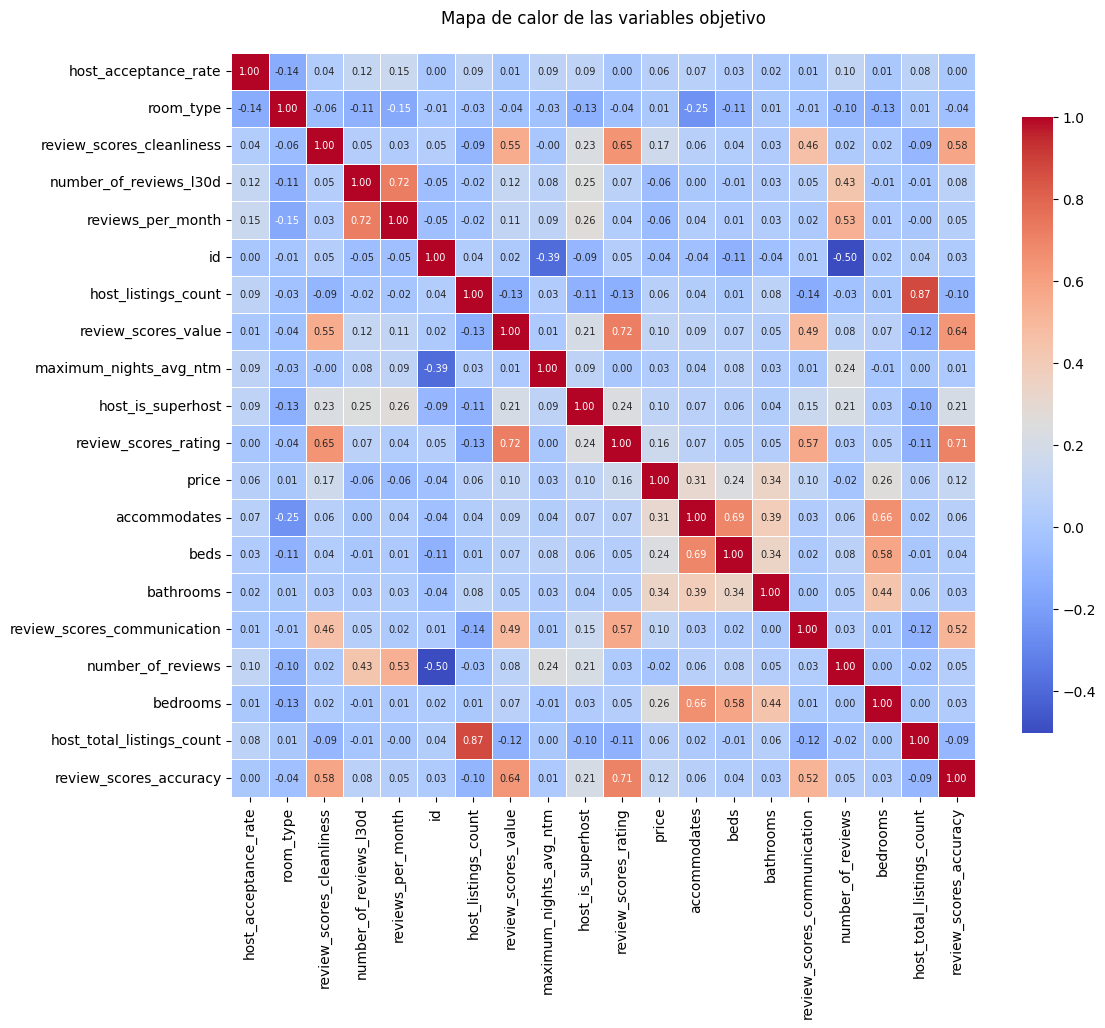

In [1795]:
# Diccionario de correlaciones de la tabla
correlaciones_top = {
    "accommodates": ["beds", "bedrooms", "bathrooms"],
    "bedrooms": ["accommodates", "beds", "bathrooms"],
    "host_acceptance_rate": ["reviews_per_month", "room_type", "number_of_reviews_l30d"],
    "host_is_superhost": ["reviews_per_month", "number_of_reviews_l30d", "review_scores_rating"],
    "host_total_listings_count": ["host_listings_count", "review_scores_communication", "review_scores_value"],
    "id": ["number_of_reviews", "maximum_nights_avg_ntm", "maximum_nights"],
    "price": ["bathrooms", "accommodates", "bedrooms"],
    "review_scores_value": ["review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness"],
    "reviews_per_month": ["number_of_reviews_l30d", "number_of_reviews", "host_is_superhost"],
    "room_type": ["accommodates", "reviews_per_month", "host_acceptance_rate"]
}

# Crear un conjunto de variables seleccionadas
variables_seleccionadas = set(variables)

# Agregar las 3 variables más correlacionadas de cada objetivo
for var, top_vars in correlaciones_top.items():
    variables_seleccionadas.update(top_vars)

# Convertir a lista y limitar a 15-20 variables
variables_finales = list(variables_seleccionadas)[:20]  # Ajustar si hay más de 20

# Filtrar el dataframe con las variables seleccionadas
df_reducido = df[variables_finales]

# Calcular la matriz de correlación
corr_reducida = df_reducido.corr()

# Ajustar tamaño del mapa de calor
plt.figure(figsize=(12, 10))

# Generar el mapa de calor sin máscara (para evitar la pirámide)
sns.heatmap(
    corr_reducida, 
    cmap="coolwarm", 
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    square=True, 
    annot_kws={"size": 7},  
    cbar_kws={"shrink": 0.8}
)
plt.title("Mapa de calor de las variables objetivo\n")

# Mejorar etiquetas
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Mostrar el gráfico
plt.show()



# **Variable 1: id**

**Lineal Simple**

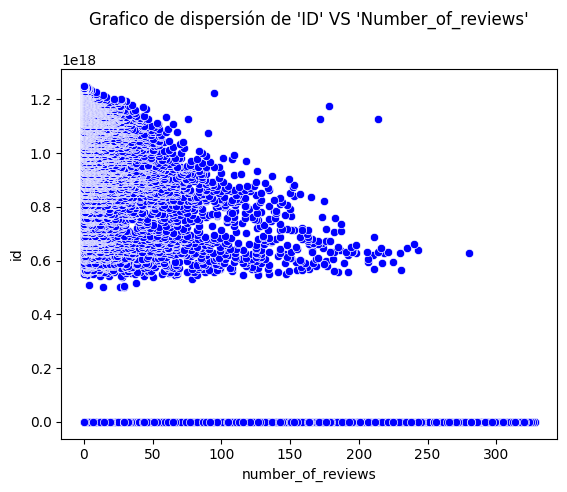

In [1796]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(id vs number_of_reviews)
sns.scatterplot(x='number_of_reviews', y='id', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'ID' VS 'Number_of_reviews'\n")

# Mostrar la gráfica
plt.show()

In [1797]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['number_of_reviews']]
Var_Dep= df['id']

In [1798]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1799]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1800]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['number_of_reviews'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-3.84646991e+15]),
 'rank_': 1,
 'singular_': array([7659.40889167]),
 'intercept_': np.float64(7.554027649620733e+17)}

In [1801]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.25051651490339355

In [1802]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['number_of_reviews']])
y_pred

array([5.51539859e+17, 4.39992232e+17, 3.43830484e+17, ...,
       7.55402765e+17, 7.55402765e+17, 7.55402765e+17], shape=(14137,))

In [1803]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(31, 'Predicciones_id_simple', y_pred)
df  

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,53.0,0.0,4.87,4.89,4.85,4.91,4.58,4.75,0.33,5.515399e+17
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,82.0,0.0,4.83,4.85,4.85,4.90,4.80,4.75,0.56,4.399922e+17
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,107.0,0.0,4.85,4.92,4.93,4.97,4.79,4.78,0.73,3.438305e+17
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,36.0,0.0,4.83,4.97,4.91,4.89,4.82,4.82,0.21,6.169298e+17
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,25.0,0.0,4.84,4.88,4.96,4.96,4.75,4.71,0.17,6.592410e+17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.0,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.0,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.0,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.0,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17


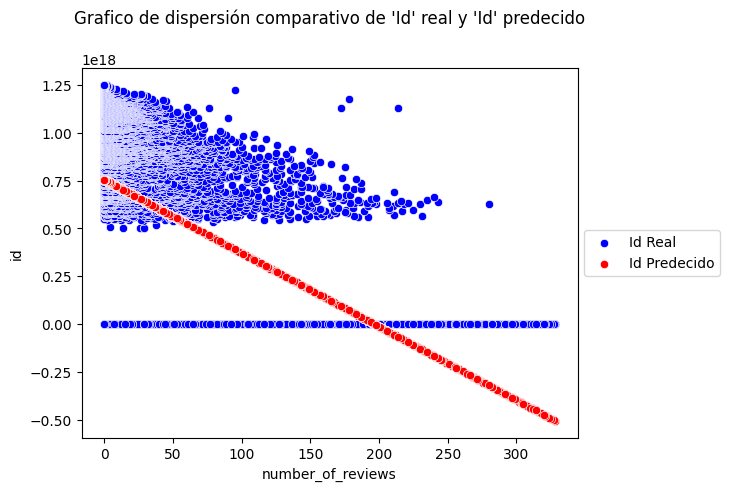

In [1804]:
sns.scatterplot(x='number_of_reviews', y='id', color="blue", data=df)
sns.scatterplot(x='number_of_reviews', y='Predicciones_id_simple', color="red", data=df)
#sns.lineplot(x='number_of_reviews', y='Predicciones_id_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Id' real y 'Id' predecido\n")

# Agregar la leyenda manualmente
plt.legend(labels=["Id Real", "Id Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1805]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_id","determinacion")] = coef_Deter
coef_Deter

0.25051651490339355

In [1806]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_id","correlacion")] = coef_Correl
coef_Correl

np.float64(0.5005162483909924)

**Lineal Múltiple**

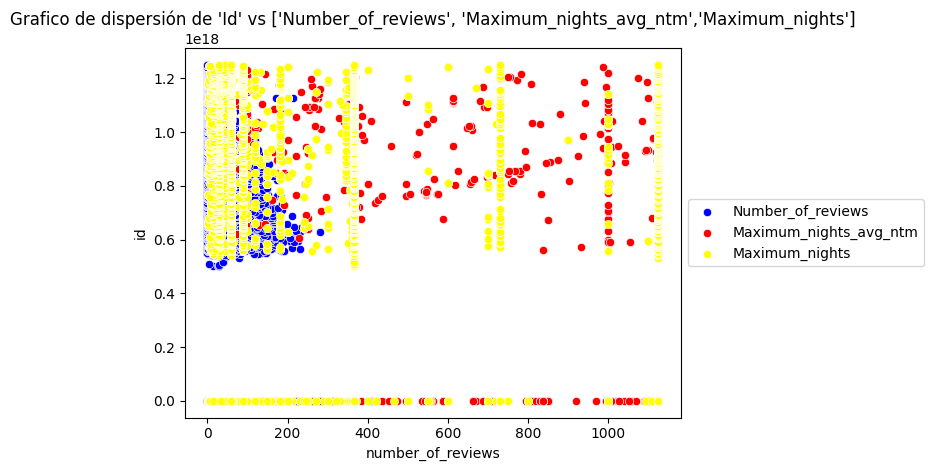

In [1807]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(id vs [number_of_reviews, maximum_nights_avg_ntm, maximum_nights])
sns.scatterplot(x='number_of_reviews', y='id', color="blue", data=df)
sns.scatterplot(x='maximum_nights_avg_ntm', y='id', color="red", data=df)
sns.scatterplot(x='maximum_nights', y='id', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Id' vs ['Number_of_reviews', 'Maximum_nights_avg_ntm','Maximum_nights']")

# Agregar la leyenda manualmente
plt.legend(labels=["Number_of_reviews", "Maximum_nights_avg_ntm", "Maximum_nights"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1808]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['number_of_reviews', 'maximum_nights_avg_ntm', 'maximum_nights']]
Var_Dep= df['id']

In [1809]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1810]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1811]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['number_of_reviews', 'maximum_nights_avg_ntm', 'maximum_nights'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([-3.37626747e+15, -2.04140174e+14, -2.34625917e+14]),
 'rank_': 3,
 'singular_': array([63698.03111362, 35698.28338006,  7420.87700377]),
 'intercept_': np.float64(9.808910303823718e+17)}

In [1812]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.3585870794814646

In [1813]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['number_of_reviews', 'maximum_nights_avg_ntm', 'maximum_nights']])
y_pred

array([7.22970958e+17, 2.10425246e+17, 5.80141463e+17, ...,
       8.20741407e+17, 8.20741407e+17, 8.20741407e+17], shape=(14137,))

In [1814]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(32, 'Predicciones_id_multiple', y_pred)
df  

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.0,4.87,4.89,4.85,4.91,4.58,4.75,0.33,5.515399e+17,7.229710e+17
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.0,4.83,4.85,4.85,4.90,4.80,4.75,0.56,4.399922e+17,2.104252e+17
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.0,4.85,4.92,4.93,4.97,4.79,4.78,0.73,3.438305e+17,5.801415e+17
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.0,4.83,4.97,4.91,4.89,4.82,4.82,0.21,6.169298e+17,8.396009e+17
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.0,4.84,4.88,4.96,4.96,4.75,4.71,0.17,6.592410e+17,4.028725e+17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.0,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17


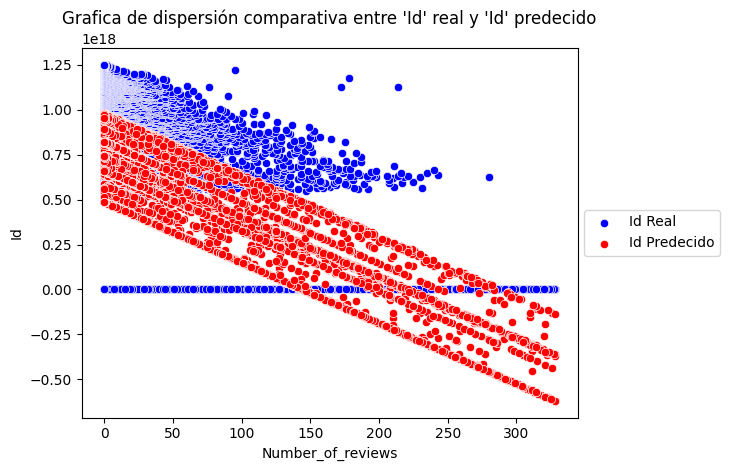

In [1815]:
sns.scatterplot(x='number_of_reviews', y='id', color="blue", data=df)
sns.scatterplot(x='number_of_reviews', y='Predicciones_id_multiple', color="red", data=df)
#sns.lineplot(x='number_of_reviews', y='Predicciones_id_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Id' real y 'Id' predecido")
plt.xlabel("Number_of_reviews")
plt.ylabel("Id")

# Agregar la leyenda manualmente
plt.legend(labels=["Id Real", "Id Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1816]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_id","determinacion")] = coef_Deter
coef_Deter

0.3585870794814646

In [1817]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_id","correlacion")] = coef_Correl
coef_Correl

np.float64(0.5988214086699511)

# **Variable 2: host_acceptance_rate**

**Lineal Simple**

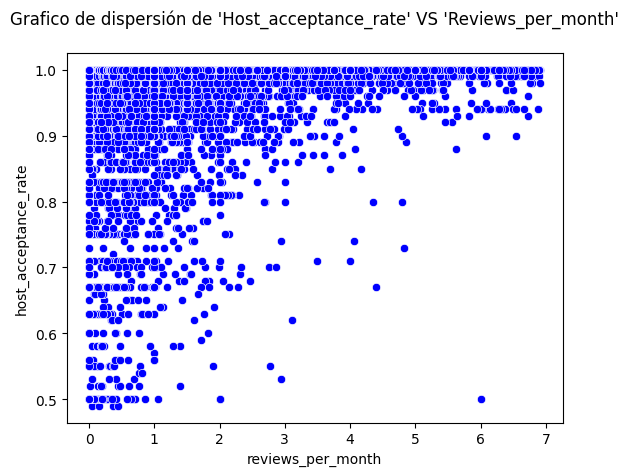

In [1818]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(host_acceptance_rate vs reviews_per_month)
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_acceptance_rate' VS 'Reviews_per_month'\n")

# Mostrar la gráfica
plt.show()

In [1819]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month']]
Var_Dep= df['host_acceptance_rate']

In [1820]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1821]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1822]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.00654088]),
 'rank_': 1,
 'singular_': array([185.97961551]),
 'intercept_': np.float64(0.9655697514279333)}

In [1823]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.02104633936862521

In [1824]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month']])
y_pred

array([0.96772824, 0.96923265, 0.9703446 , ..., 0.96556975, 0.96556975,
       0.96556975], shape=(14137,))

In [1825]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(33, 'Predicciones_host_acceptance_rate_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,4.87,4.89,4.85,4.91,4.58,4.75,0.33,5.515399e+17,7.229710e+17,0.967728
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.83,4.85,4.85,4.90,4.80,4.75,0.56,4.399922e+17,2.104252e+17,0.969233
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,4.85,4.92,4.93,4.97,4.79,4.78,0.73,3.438305e+17,5.801415e+17,0.970345
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.83,4.97,4.91,4.89,4.82,4.82,0.21,6.169298e+17,8.396009e+17,0.966943
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,4.84,4.88,4.96,4.96,4.75,4.71,0.17,6.592410e+17,4.028725e+17,0.966682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,4.90,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570


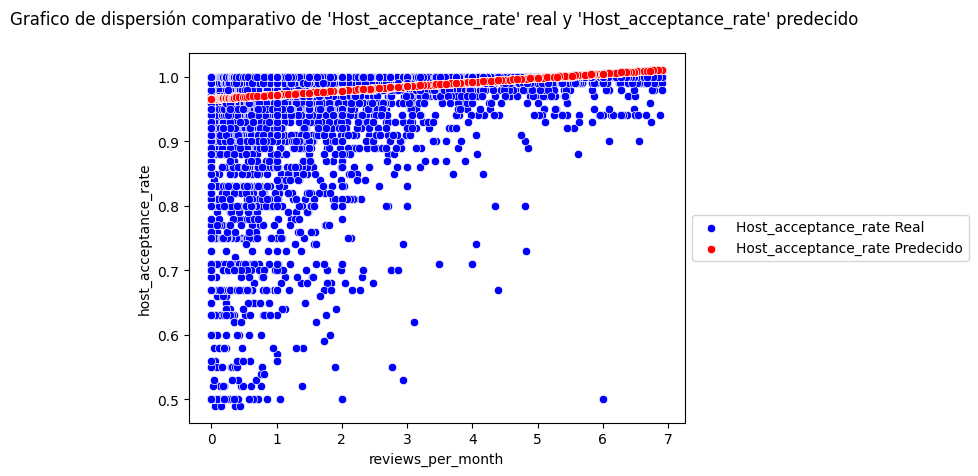

In [1826]:
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_simple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Host_acceptance_rate' real y 'Host_acceptance_rate' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_acceptance_rate Real", "Host_acceptance_rate Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1827]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.02104633936862521

In [1828]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.1450735653681442)

**Lineal Múltiple**

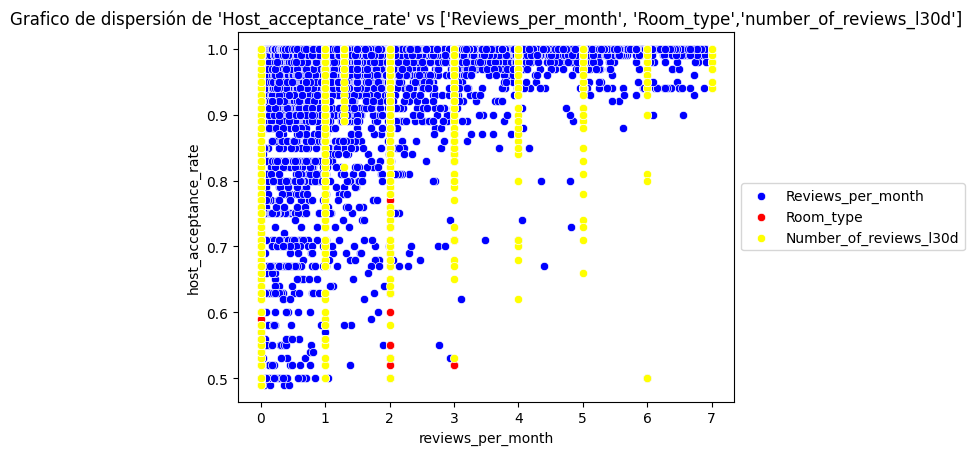

In [1829]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(host_acceptance_rate vs [reviews_per_month, room_type, number_of_reviews_l30d])
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)
sns.scatterplot(x='room_type', y='host_acceptance_rate', color="red", data=df)
sns.scatterplot(x='number_of_reviews_l30d', y='host_acceptance_rate', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_acceptance_rate' vs ['Reviews_per_month', 'Room_type','number_of_reviews_l30d']")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month", "Room_type", "Number_of_reviews_l30d"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1830]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month', 'room_type', 'number_of_reviews_l30d']]
Var_Dep= df['host_acceptance_rate']

In [1831]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1832]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1833]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month', 'room_type', 'number_of_reviews_l30d'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.00468915, -0.01568624,  0.001267  ]),
 'rank_': 3,
 'singular_': array([260.82011061, 103.80119455,  64.26619867]),
 'intercept_': np.float64(0.9692100417892684)}

In [1834]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.03608554882516757

In [1835]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month', 'room_type', 'number_of_reviews_l30d']])
y_pred

array([0.97075746, 0.97183596, 0.97263312, ..., 0.96921004, 0.96921004,
       0.96921004], shape=(14137,))

In [1836]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(34, 'Predicciones_host_acceptance_rate_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,4.89,4.85,4.91,4.58,4.75,0.33,5.515399e+17,7.229710e+17,0.967728,0.970757
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.85,4.85,4.90,4.80,4.75,0.56,4.399922e+17,2.104252e+17,0.969233,0.971836
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,4.92,4.93,4.97,4.79,4.78,0.73,3.438305e+17,5.801415e+17,0.970345,0.972633
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.97,4.91,4.89,4.82,4.82,0.21,6.169298e+17,8.396009e+17,0.966943,0.970195
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,4.88,4.96,4.96,4.75,4.71,0.17,6.592410e+17,4.028725e+17,0.966682,0.970007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,4.90,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210


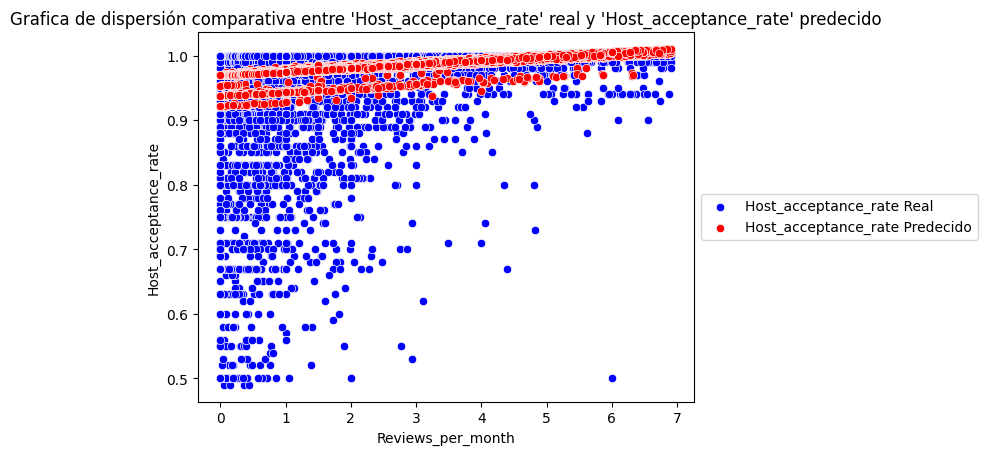

In [1837]:
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_multiple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Host_acceptance_rate' real y 'Host_acceptance_rate' predecido")
plt.xlabel("Reviews_per_month")
plt.ylabel("Host_acceptance_rate")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_acceptance_rate Real", "Host_acceptance_rate Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1838]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.03608554882516757

In [1839]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.18996196678590052)

# **Variable 3: host_is_superhost**

**Lineal Simple**

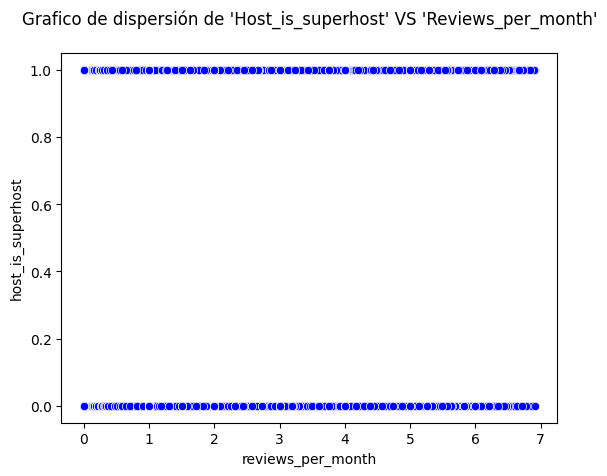

In [1840]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(host_is_superhost vs reviews_per_month)
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_is_superhost' VS 'Reviews_per_month'\n")

# Mostrar la gráfica
plt.show()

In [1841]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month']]
Var_Dep= df['host_is_superhost']

In [1842]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1843]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1844]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.08150487]),
 'rank_': 1,
 'singular_': array([185.97961551]),
 'intercept_': np.float64(0.26525832647617376)}

In [1845]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.06861959168474752

In [1846]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month']])
y_pred

array([0.29215493, 0.31090105, 0.32475688, ..., 0.26525833, 0.26525833,
       0.26525833], shape=(14137,))

In [1847]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(35, 'Predicciones_host_is_superhost_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,4.85,4.91,4.58,4.75,0.33,5.515399e+17,7.229710e+17,0.967728,0.970757,0.292155
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.85,4.90,4.80,4.75,0.56,4.399922e+17,2.104252e+17,0.969233,0.971836,0.310901
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,4.93,4.97,4.79,4.78,0.73,3.438305e+17,5.801415e+17,0.970345,0.972633,0.324757
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.91,4.89,4.82,4.82,0.21,6.169298e+17,8.396009e+17,0.966943,0.970195,0.282374
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,4.96,4.96,4.75,4.71,0.17,6.592410e+17,4.028725e+17,0.966682,0.970007,0.279114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,4.90,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258


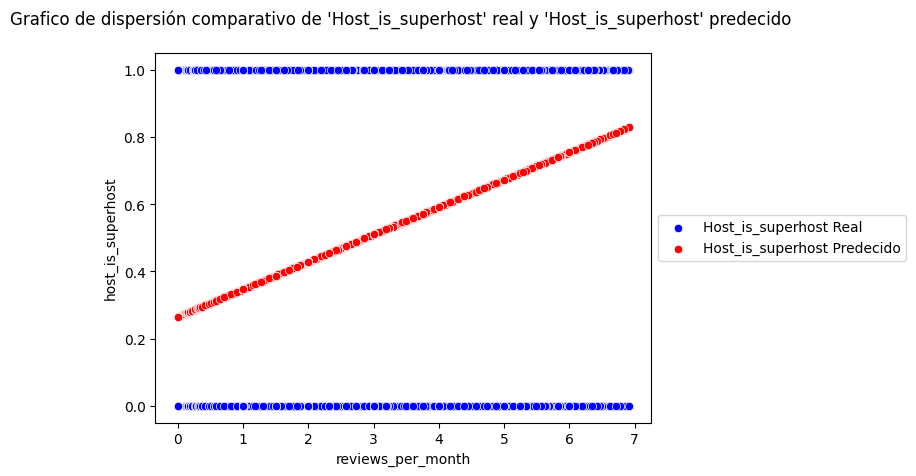

In [1848]:
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_is_superhost_simple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_is_superhost_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Host_is_superhost' real y 'Host_is_superhost' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_is_superhost Real", "Host_is_superhost Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1849]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.06861959168474752

In [1850]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.2619534151041889)

**Lineal Múltiple**

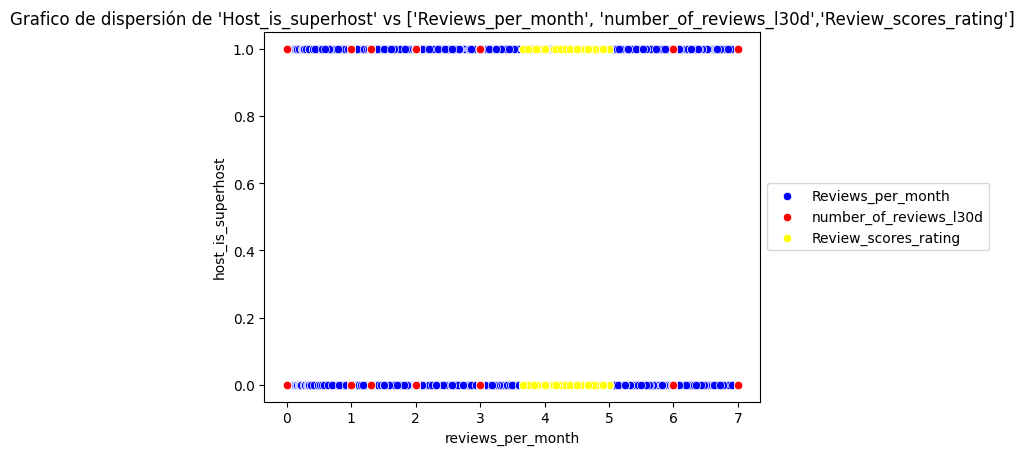

In [1851]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(host_is_superhost vs [reviews_per_month, number_of_reviews_l30d, review_scores_rating])
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)
sns.scatterplot(x='number_of_reviews_l30d', y='host_is_superhost', color="red", data=df)
sns.scatterplot(x='review_scores_rating', y='host_is_superhost', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_is_superhost' vs ['Reviews_per_month', 'number_of_reviews_l30d','Review_scores_rating']")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month", "number_of_reviews_l30d", "Review_scores_rating"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1852]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month', 'number_of_reviews_l30d', 'review_scores_rating']]
Var_Dep= df['host_is_superhost']

In [1853]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1854]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1855]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month', 'number_of_reviews_l30d',
        'review_scores_rating'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([0.05748583, 0.02631049, 0.4723686 ]),
 'rank_': 3,
 'singular_': array([260.6576138 , 103.71300087,  27.26759337]),
 'intercept_': np.float64(-2.0032692877019156)}

In [1856]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.12482150671795122

In [1857]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month', 'number_of_reviews_l30d', 'review_scores_rating']])
y_pred

array([0.31613613, 0.31046312, 0.32968308, ..., 0.31133686, 0.31133686,
       0.31133686], shape=(14137,))

In [1858]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(36, 'Predicciones_host_is_superhost_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,4.91,4.58,4.75,0.33,5.515399e+17,7.229710e+17,0.967728,0.970757,0.292155,0.316136
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.90,4.80,4.75,0.56,4.399922e+17,2.104252e+17,0.969233,0.971836,0.310901,0.310463
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,4.97,4.79,4.78,0.73,3.438305e+17,5.801415e+17,0.970345,0.972633,0.324757,0.329683
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.89,4.82,4.82,0.21,6.169298e+17,8.396009e+17,0.966943,0.970195,0.282374,0.290343
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,4.96,4.75,4.71,0.17,6.592410e+17,4.028725e+17,0.966682,0.970007,0.279114,0.292767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,5.00,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337


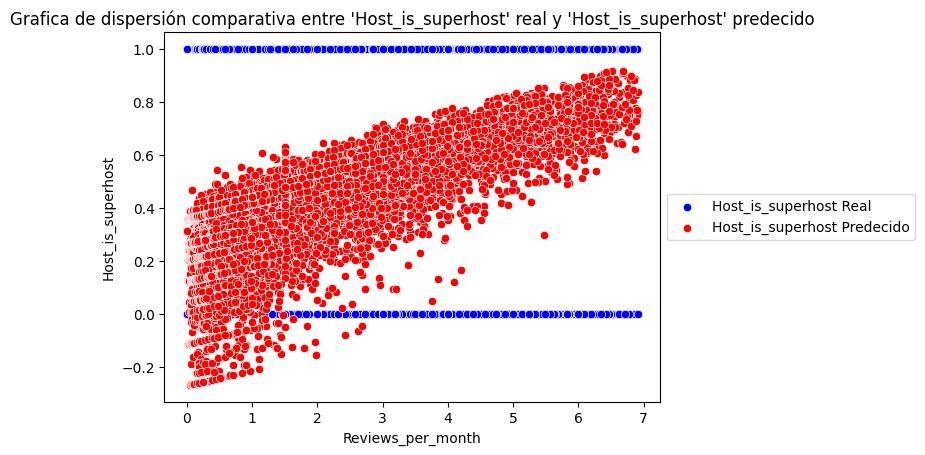

In [1859]:
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_is_superhost_multiple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_is_superhost_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Host_is_superhost' real y 'Host_is_superhost' predecido")
plt.xlabel("Reviews_per_month")
plt.ylabel("Host_is_superhost")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_is_superhost Real", "Host_is_superhost Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1860]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.12482150671795122

In [1861]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.3533008727953431)

# **Variable 4: host_total_listings_count**

**Lineal Simple**

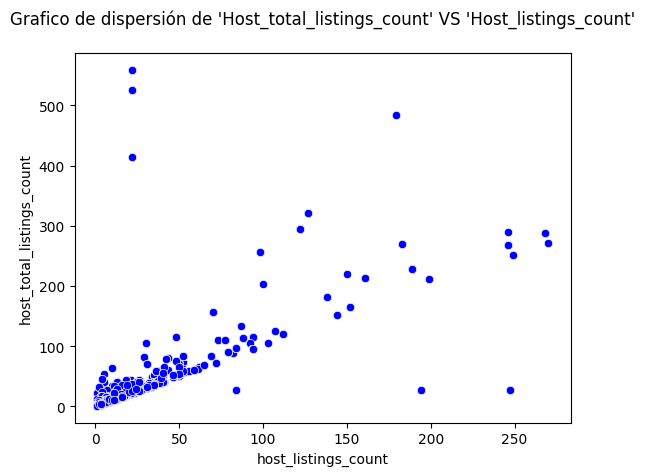

In [1862]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(host_total_listings_count vs host_listings_count)
sns.scatterplot(x='host_listings_count', y='host_total_listings_count', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_total_listings_count' VS 'Host_listings_count'\n")

# Mostrar la gráfica
plt.show()

In [1863]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['host_listings_count']]
Var_Dep= df['host_total_listings_count']

In [1864]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1865]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1866]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_listings_count'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.17663783]),
 'rank_': 1,
 'singular_': array([4873.95163344]),
 'intercept_': np.float64(1.8269781236607763)}

In [1867]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.7647861706639248

In [1868]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['host_listings_count']])
y_pred

array([13.59335642, 13.59335642, 13.59335642, ..., 14.76999425,
        5.35689161,  5.35689161], shape=(14137,))

In [1869]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(37, 'Predicciones_host_total_listings_count_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,4.58,4.75,0.33,5.515399e+17,7.229710e+17,0.967728,0.970757,0.292155,0.316136,13.593356
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.80,4.75,0.56,4.399922e+17,2.104252e+17,0.969233,0.971836,0.310901,0.310463,13.593356
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,4.79,4.78,0.73,3.438305e+17,5.801415e+17,0.970345,0.972633,0.324757,0.329683,13.593356
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.82,4.82,0.21,6.169298e+17,8.396009e+17,0.966943,0.970195,0.282374,0.290343,13.593356
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,4.75,4.71,0.17,6.592410e+17,4.028725e+17,0.966682,0.970007,0.279114,0.292767,13.593356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,13.593356
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,4.180254
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,14.769994
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,4.80,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,5.356892


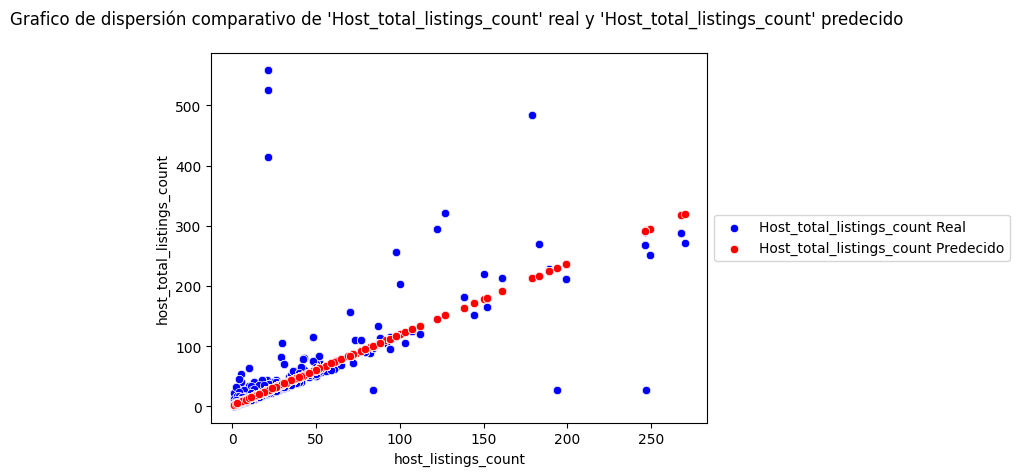

In [1870]:
sns.scatterplot(x='host_listings_count', y='host_total_listings_count', color="blue", data=df)
sns.scatterplot(x='host_listings_count', y='Predicciones_host_total_listings_count_simple', color="red", data=df)
#sns.lineplot(x='host_listings_count', y='Predicciones_host_total_listings_count_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Host_total_listings_count' real y 'Host_total_listings_count' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_total_listings_count Real", "Host_total_listings_count Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1871]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_host_total_listings_count","determinacion")] = coef_Deter
coef_Deter

0.7647861706639248

In [1872]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_host_total_listings_count","correlacion")] = coef_Correl
coef_Correl

np.float64(0.8745205375884119)

**Lineal Múltiple**

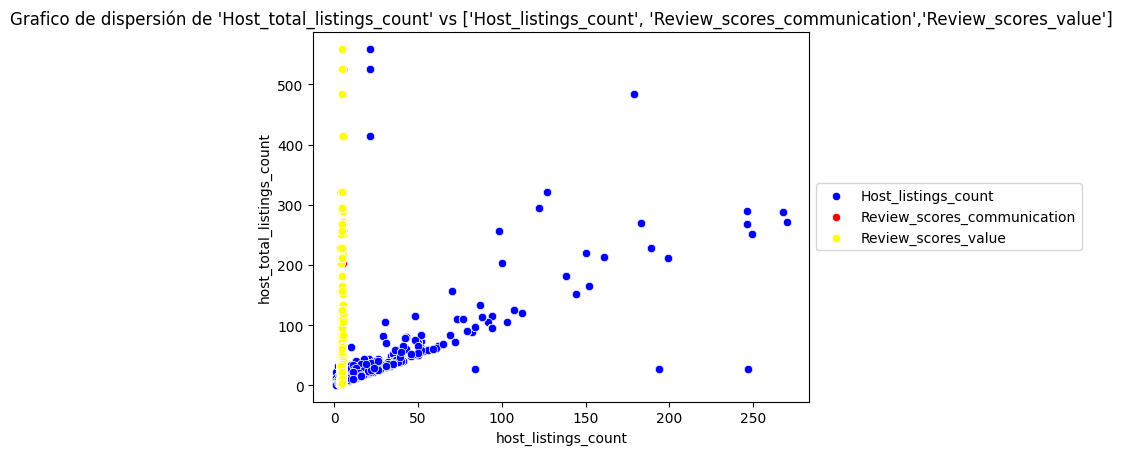

In [1873]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(room_type vs [host_listings_count, review_scores_communication, review_scores_value])
sns.scatterplot(x='host_listings_count', y='host_total_listings_count', color="blue", data=df)
sns.scatterplot(x='review_scores_communication', y='host_total_listings_count', color="red", data=df)
sns.scatterplot(x='review_scores_value', y='host_total_listings_count', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_total_listings_count' vs ['Host_listings_count', 'Review_scores_communication','Review_scores_value']")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_listings_count", "Review_scores_communication", "Review_scores_value"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1874]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['host_listings_count', 'review_scores_communication', 'review_scores_value']]
Var_Dep= df['host_total_listings_count']

In [1875]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1876]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1877]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_listings_count', 'review_scores_communication',
        'review_scores_value'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 1.17678904,  1.22481621, -0.7627171 ]),
 'rank_': 3,
 'singular_': array([4873.9537113 ,   29.33310872,   16.13534045]),
 'intercept_': np.float64(-0.5438391114407537)}

In [1878]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.7647988297232726

In [1879]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['host_listings_count', 'review_scores_communication', 'review_scores_value']])
y_pred

array([13.61499269, 13.60274453, 13.66560015, ..., 14.86387934,
        5.44956698,  5.44956698], shape=(14137,))

In [1880]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(38, 'Predicciones_host_total_listings_count_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,4.75,0.33,5.515399e+17,7.229710e+17,0.967728,0.970757,0.292155,0.316136,13.593356,13.614993
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.75,0.56,4.399922e+17,2.104252e+17,0.969233,0.971836,0.310901,0.310463,13.593356,13.602745
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,4.78,0.73,3.438305e+17,5.801415e+17,0.970345,0.972633,0.324757,0.329683,13.593356,13.665600
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.82,0.21,6.169298e+17,8.396009e+17,0.966943,0.970195,0.282374,0.290343,13.593356,13.537106
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,4.71,0.17,6.592410e+17,4.028725e+17,0.966682,0.970007,0.279114,0.292767,13.593356,13.706742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,13.593356,13.687090
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,4.180254,4.272778
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,14.769994,14.863879
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,4.80,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,5.356892,5.449567


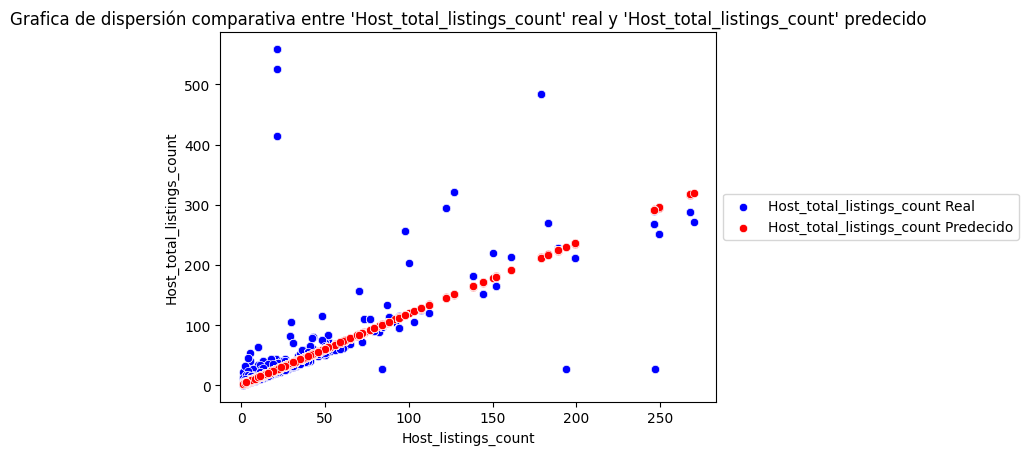

In [1881]:
sns.scatterplot(x='host_listings_count', y='host_total_listings_count', color="blue", data=df)
sns.scatterplot(x='host_listings_count', y='Predicciones_host_total_listings_count_multiple', color="red", data=df)
#sns.lineplot(x='host_listings_count', y='Predicciones_host_total_listings_count_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Host_total_listings_count' real y 'Host_total_listings_count' predecido")
plt.xlabel("Host_listings_count")
plt.ylabel("Host_total_listings_count")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_total_listings_count Real", "Host_total_listings_count Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1882]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_host_total_listings_count","determinacion")] = coef_Deter
coef_Deter

0.7647988297232726

In [1883]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_host_total_listings_count","correlacion")] = coef_Correl
coef_Correl

np.float64(0.8745277752726168)

# **Variable 5: room_type**

**Lineal Simple**

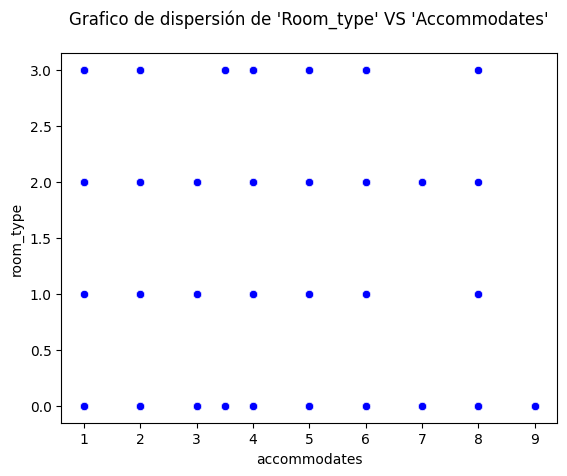

In [1884]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(room_type vs accommodates)
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Room_type' VS 'Accommodates'\n")

# Mostrar la gráfica
plt.show()

In [1885]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates']]
Var_Dep= df['room_type']

In [1886]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1887]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1888]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-0.08902253]),
 'rank_': 1,
 'singular_': array([181.67871839]),
 'intercept_': np.float64(0.47493396983857483)}

In [1889]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.06172385112981249

In [1890]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates']])
y_pred

array([0.16335512, 0.11884385, 0.29688891, ..., 0.11884385, 0.20786638,
       0.29688891], shape=(14137,))

In [1891]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(39, 'Predicciones_room_type_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.33,5.515399e+17,7.229710e+17,0.967728,0.970757,0.292155,0.316136,13.593356,13.614993,0.163355
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.56,4.399922e+17,2.104252e+17,0.969233,0.971836,0.310901,0.310463,13.593356,13.602745,0.118844
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.73,3.438305e+17,5.801415e+17,0.970345,0.972633,0.324757,0.329683,13.593356,13.665600,0.296889
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.21,6.169298e+17,8.396009e+17,0.966943,0.970195,0.282374,0.290343,13.593356,13.537106,0.118844
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.17,6.592410e+17,4.028725e+17,0.966682,0.970007,0.279114,0.292767,13.593356,13.706742,0.296889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,13.593356,13.687090,0.118844
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,4.180254,4.272778,0.296889
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,14.769994,14.863879,0.118844
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.00,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,5.356892,5.449567,0.207866


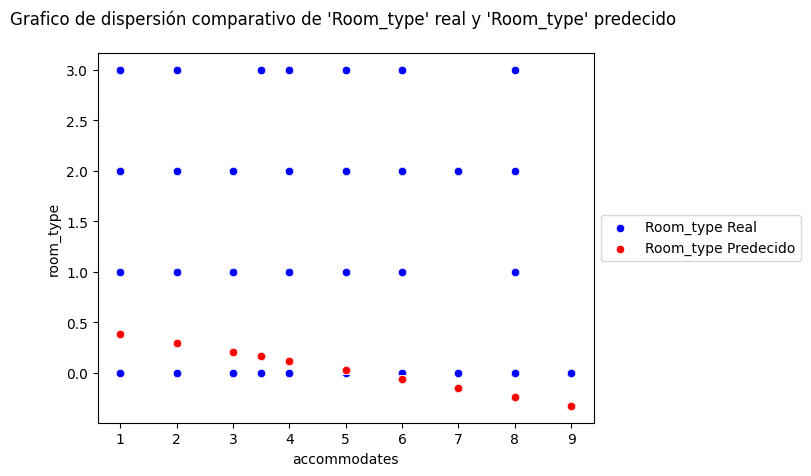

In [1892]:
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_room_type_simple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_room_type_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Room_type' real y 'Room_type' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Room_type Real", "Room_type Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1893]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_room_type","determinacion")] = coef_Deter
coef_Deter

0.06172385112981249

In [1894]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_room_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.24844285284510095)

**Lineal Múltiple**

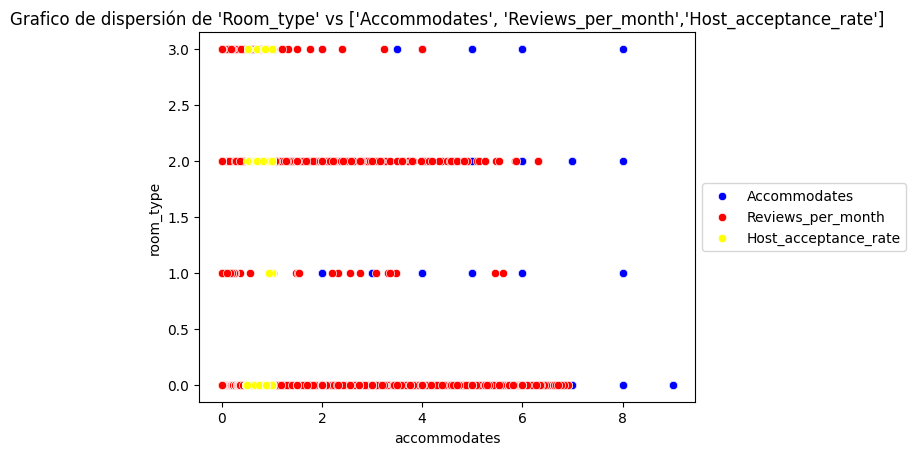

In [1895]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(room_type vs [accommodates, reviews_per_month, host_acceptance_rate])
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='room_type', color="red", data=df)
sns.scatterplot(x='host_acceptance_rate', y='room_type', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Room_type' vs ['Accommodates', 'Reviews_per_month','Host_acceptance_rate']")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates", "Reviews_per_month", "Host_acceptance_rate"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1896]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates', 'reviews_per_month', 'host_acceptance_rate']]
Var_Dep= df['room_type']

In [1897]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1898]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1899]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates', 'reviews_per_month', 'host_acceptance_rate'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([-0.0848801 , -0.0437288 , -0.83366155]),
 'rank_': 3,
 'singular_': array([187.79017064, 179.81146084,   8.28106704]),
 'intercept_': np.float64(1.337687215331024)}

In [1900]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.092619722320748

In [1901]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates', 'reviews_per_month', 'host_acceptance_rate']])
y_pred

array([0.1925148 , 0.14001712, 0.30234344, ..., 0.16450525, 0.34942474,
       0.43430484], shape=(14137,))

In [1902]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(40, 'Predicciones_room_type_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,5.515399e+17,7.229710e+17,0.967728,0.970757,0.292155,0.316136,13.593356,13.614993,0.163355,0.192515
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,4.399922e+17,2.104252e+17,0.969233,0.971836,0.310901,0.310463,13.593356,13.602745,0.118844,0.140017
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,3.438305e+17,5.801415e+17,0.970345,0.972633,0.324757,0.329683,13.593356,13.665600,0.296889,0.302343
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,6.169298e+17,8.396009e+17,0.966943,0.970195,0.282374,0.290343,13.593356,13.537106,0.118844,0.155322
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,6.592410e+17,4.028725e+17,0.966682,0.970007,0.279114,0.292767,13.593356,13.706742,0.296889,0.326832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,13.593356,13.687090,0.118844,0.164505
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,4.180254,4.272778,0.296889,0.334265
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,14.769994,14.863879,0.118844,0.164505
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,7.554028e+17,8.207414e+17,0.965570,0.969210,0.265258,0.311337,5.356892,5.449567,0.207866,0.349425


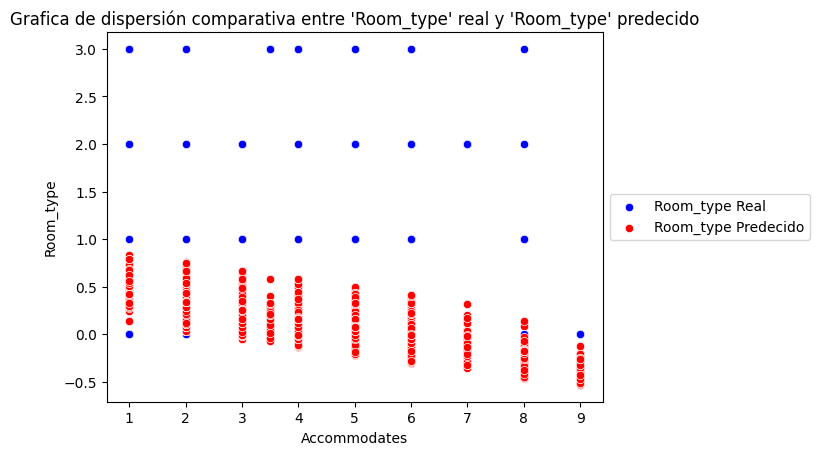

In [1903]:
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_room_type_multiple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_room_type_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Room_type' real y 'Room_type' predecido")
plt.xlabel("Accommodates")
plt.ylabel("Room_type")

# Agregar la leyenda manualmente
plt.legend(labels=["Room_type Real", "Room_type Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1904]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_room_type","determinacion")] = coef_Deter
coef_Deter

0.092619722320748

In [1905]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_room_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.3043348851524386)

# **Variable 6: accommodates**

**Lineal Simple**

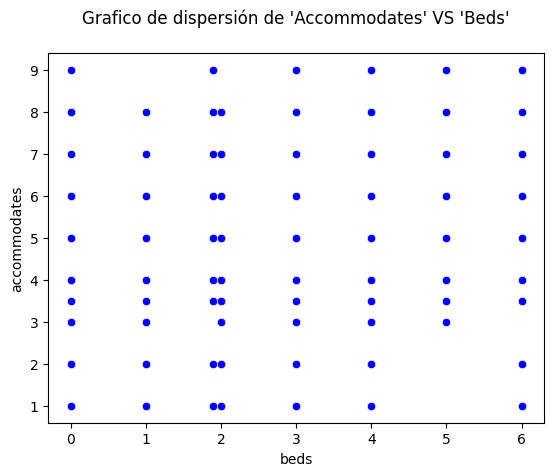

In [1906]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(accommodates vs beds)
sns.scatterplot(x='beds', y='accommodates', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Accommodates' VS 'Beds'\n")

# Mostrar la gráfica
plt.show()

In [1907]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['beds']]
Var_Dep= df['accommodates']

In [1908]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1909]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1910]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['beds'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.00124254]),
 'rank_': 1,
 'singular_': array([125.88860009]),
 'intercept_': np.float64(1.6272801480946886)}

In [1911]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.481330387140843

In [1912]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['beds']])
y_pred

array([3.52964098, 2.62852269, 3.62976523, ..., 3.62976523, 3.62976523,
       2.62852269], shape=(14137,))

In [1913]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(41, 'Predicciones_accommodates_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,7.229710e+17,0.967728,0.970757,0.292155,0.316136,13.593356,13.614993,0.163355,0.192515,3.529641
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,2.104252e+17,0.969233,0.971836,0.310901,0.310463,13.593356,13.602745,0.118844,0.140017,2.628523
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,5.801415e+17,0.970345,0.972633,0.324757,0.329683,13.593356,13.665600,0.296889,0.302343,3.629765
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,8.396009e+17,0.966943,0.970195,0.282374,0.290343,13.593356,13.537106,0.118844,0.155322,3.629765
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,4.028725e+17,0.966682,0.970007,0.279114,0.292767,13.593356,13.706742,0.296889,0.326832,2.628523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,8.207414e+17,0.965570,0.969210,0.265258,0.311337,13.593356,13.687090,0.118844,0.164505,3.629765
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,8.207414e+17,0.965570,0.969210,0.265258,0.311337,4.180254,4.272778,0.296889,0.334265,2.628523
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,8.207414e+17,0.965570,0.969210,0.265258,0.311337,14.769994,14.863879,0.118844,0.164505,3.629765
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,8.207414e+17,0.965570,0.969210,0.265258,0.311337,5.356892,5.449567,0.207866,0.349425,3.629765


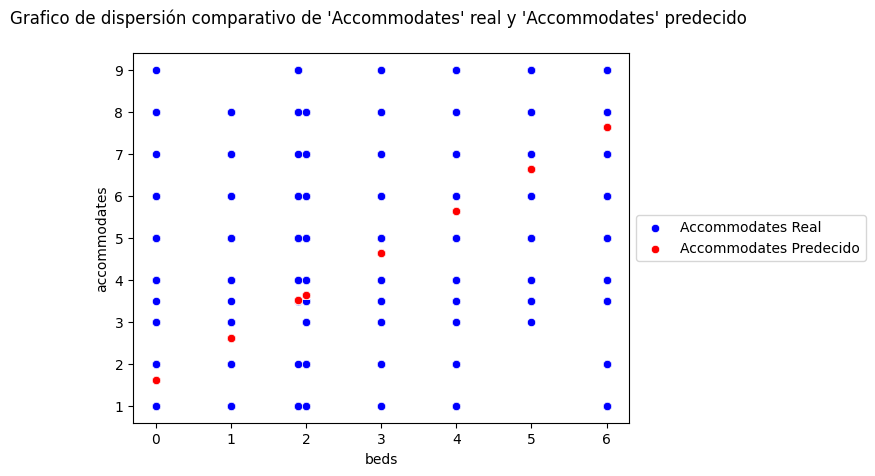

In [1914]:
sns.scatterplot(x='beds', y='accommodates', color="blue", data=df)
sns.scatterplot(x='beds', y='Predicciones_accommodates_simple', color="red", data=df)
#sns.lineplot(x='beds', y='Predicciones_accommodates_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Accommodates' real y 'Accommodates' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates Real", "Accommodates Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1915]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_accommodates","determinacion")] = coef_Deter
coef_Deter

0.481330387140843

In [1916]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.693779782885638)

**Lineal Múltiple**

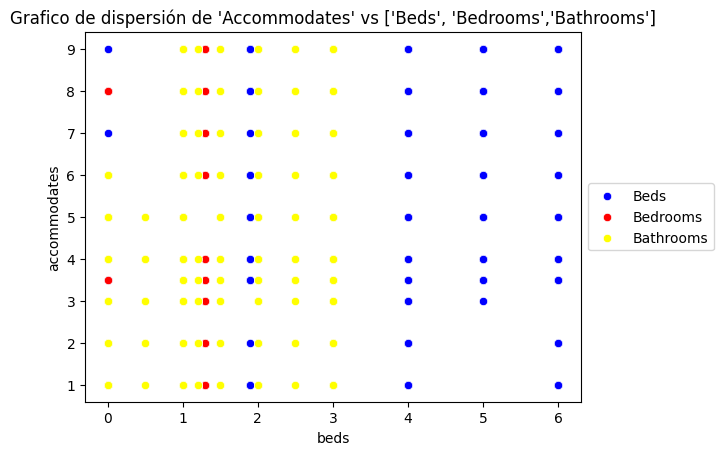

In [1917]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(accommodates vs [beds, bedrooms, bathrooms])
sns.scatterplot(x='beds', y='accommodates', color="blue", data=df)
sns.scatterplot(x='bedrooms', y='accommodates', color="red", data=df)
sns.scatterplot(x='bathrooms', y='accommodates', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Accommodates' vs ['Beds', 'Bedrooms','Bathrooms']")

# Agregar la leyenda manualmente
plt.legend(labels=["Beds", "Bedrooms", "Bathrooms"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1918]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['beds', 'bedrooms', 'bathrooms']]
Var_Dep= df['accommodates']

In [1919]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1920]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1921]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['beds', 'bedrooms', 'bathrooms'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([0.66039675, 0.8608315 , 0.27264018]),
 'rank_': 3,
 'singular_': array([137.0468227 ,  60.30229733,  39.85268883]),
 'intercept_': np.float64(0.8296260858517068)}

In [1922]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.587661391976433

In [1923]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['beds', 'bedrooms', 'bathrooms']])
y_pred

array([5.21215477, 2.62349452, 2.42305977, ..., 3.28389127, 3.28389127,
       2.62349452], shape=(14137,))

In [1924]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(42, 'Predicciones_accommodates_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.967728,0.970757,0.292155,0.316136,13.593356,13.614993,0.163355,0.192515,3.529641,5.212155
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.969233,0.971836,0.310901,0.310463,13.593356,13.602745,0.118844,0.140017,2.628523,2.623495
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.970345,0.972633,0.324757,0.329683,13.593356,13.665600,0.296889,0.302343,3.629765,2.423060
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.966943,0.970195,0.282374,0.290343,13.593356,13.537106,0.118844,0.155322,3.629765,3.283891
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.966682,0.970007,0.279114,0.292767,13.593356,13.706742,0.296889,0.326832,2.628523,2.623495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.965570,0.969210,0.265258,0.311337,13.593356,13.687090,0.118844,0.164505,3.629765,4.144723
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.965570,0.969210,0.265258,0.311337,4.180254,4.272778,0.296889,0.334265,2.628523,2.623495
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.965570,0.969210,0.265258,0.311337,14.769994,14.863879,0.118844,0.164505,3.629765,3.283891
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.965570,0.969210,0.265258,0.311337,5.356892,5.449567,0.207866,0.349425,3.629765,3.283891


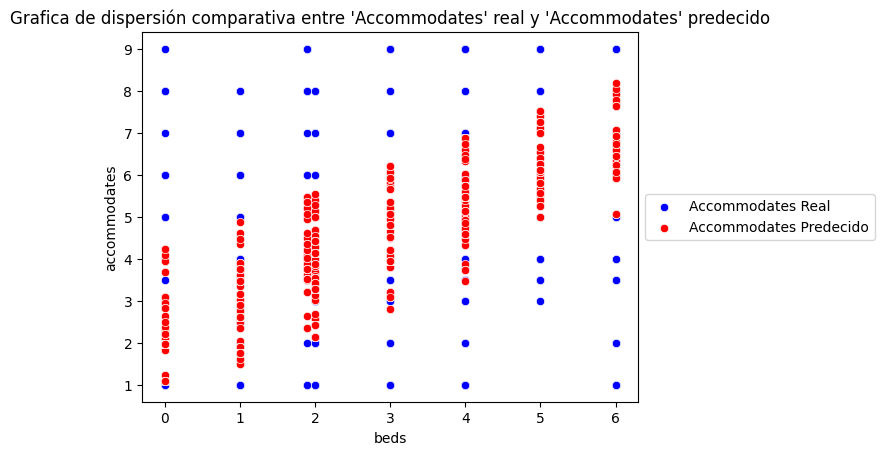

In [1925]:
sns.scatterplot(x='beds', y='accommodates', color="blue", data=df)
sns.scatterplot(x='beds', y='Predicciones_accommodates_multiple', color="red", data=df)
#sns.lineplot(x='bedrooms', y='Predicciones_accommodates_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Accommodates' real y 'Accommodates' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates Real", "Accommodates Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1926]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_accommodates","determinacion")] = coef_Deter
coef_Deter

0.587661391976433

In [1927]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.7665907591253843)

# **Variable 7: bedrooms**

**Lineal Simple**

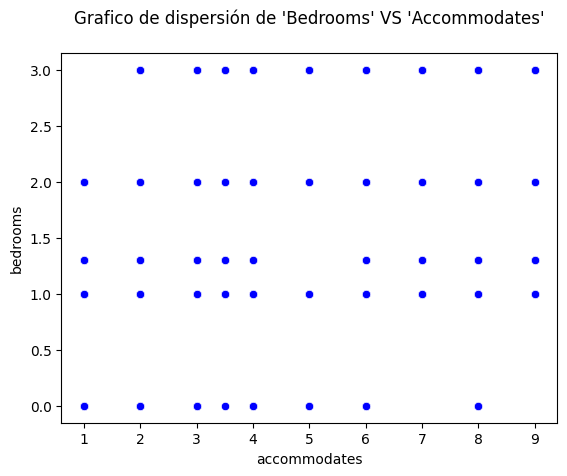

In [1928]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(bedrooms vs accommodates)
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Bedrooms' VS 'Accommodates'\n")

# Mostrar la gráfica
plt.show()

In [1929]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates']]
Var_Dep= df['bedrooms']

In [1930]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1931]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1932]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.28240235]),
 'rank_': 1,
 'singular_': array([181.67871839]),
 'intercept_': np.float64(0.316800764790959)}

In [1933]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.4389035814421073

In [1934]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates']])
y_pred

array([1.30520898, 1.44641015, 0.88160546, ..., 1.44641015, 1.1640078 ,
       0.88160546], shape=(14137,))

In [1935]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(43, 'Predicciones_bedrooms_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.970757,0.292155,0.316136,13.593356,13.614993,0.163355,0.192515,3.529641,5.212155,1.305209
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.971836,0.310901,0.310463,13.593356,13.602745,0.118844,0.140017,2.628523,2.623495,1.446410
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.972633,0.324757,0.329683,13.593356,13.665600,0.296889,0.302343,3.629765,2.423060,0.881605
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.970195,0.282374,0.290343,13.593356,13.537106,0.118844,0.155322,3.629765,3.283891,1.446410
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.970007,0.279114,0.292767,13.593356,13.706742,0.296889,0.326832,2.628523,2.623495,0.881605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.969210,0.265258,0.311337,13.593356,13.687090,0.118844,0.164505,3.629765,4.144723,1.446410
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.969210,0.265258,0.311337,4.180254,4.272778,0.296889,0.334265,2.628523,2.623495,0.881605
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.969210,0.265258,0.311337,14.769994,14.863879,0.118844,0.164505,3.629765,3.283891,1.446410
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.969210,0.265258,0.311337,5.356892,5.449567,0.207866,0.349425,3.629765,3.283891,1.164008


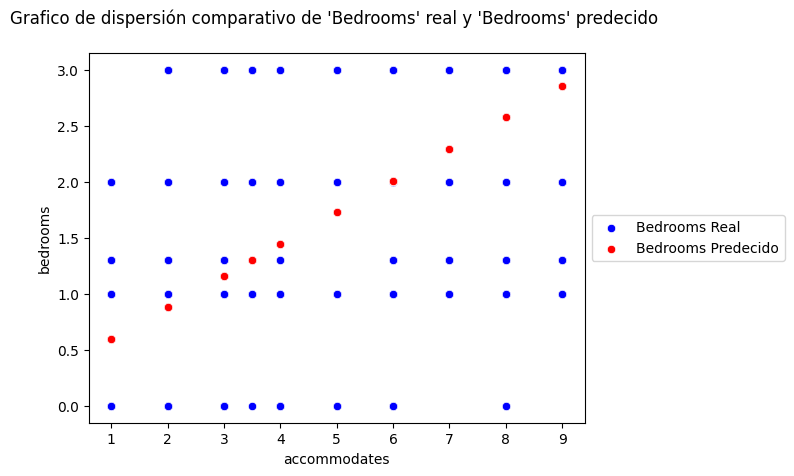

In [1936]:
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_bedrooms_simple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_bedrooms_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Bedrooms' real y 'Bedrooms' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Bedrooms Real", "Bedrooms Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1937]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_bedrooms","determinacion")] = coef_Deter
coef_Deter

0.4389035814421073

In [1938]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_bedrooms","correlacion")] = coef_Correl
coef_Correl

np.float64(0.662497985990982)

**Lineal Múltiple**

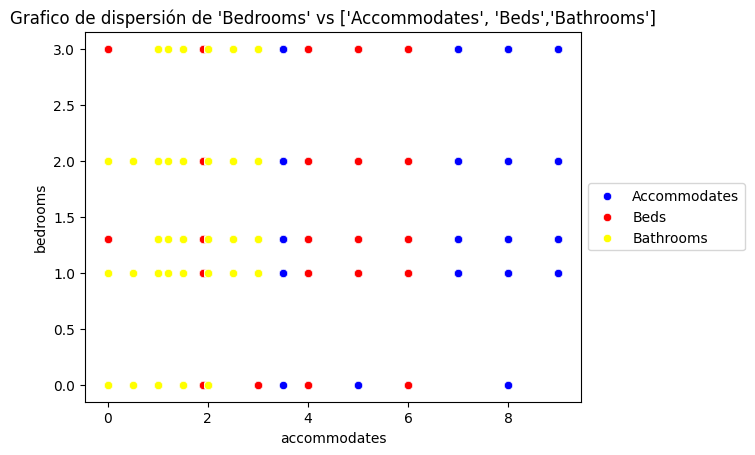

In [1939]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(bedrooms vs [accommodates, beds, bathrooms])
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)
sns.scatterplot(x='beds', y='bedrooms', color="red", data=df)
sns.scatterplot(x='bathrooms', y='bedrooms', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Bedrooms' vs ['Accommodates', 'Beds','Bathrooms']")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates", "Beds", "Bathrooms"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1940]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates', 'beds', 'bathrooms']]
Var_Dep= df['bedrooms']

In [1941]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1942]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1943]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates', 'beds', 'bathrooms'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([0.18982255, 0.1238761 , 0.3324552 ]),
 'rank_': 3,
 'singular_': array([206.95191639,  79.93307905,  42.39841608]),
 'intercept_': np.float64(0.02245519873434687)}

In [1944]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.49960128805476

In [1945]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates', 'beds', 'bathrooms']])
y_pred

array([1.58710914, 1.23807672, 0.98230771, ..., 1.36195282, 1.17213027,
       0.85843161], shape=(14137,))

In [1946]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(44, 'Predicciones_bedrooms_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.292155,0.316136,13.593356,13.614993,0.163355,0.192515,3.529641,5.212155,1.305209,1.587109
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.310901,0.310463,13.593356,13.602745,0.118844,0.140017,2.628523,2.623495,1.446410,1.238077
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.324757,0.329683,13.593356,13.665600,0.296889,0.302343,3.629765,2.423060,0.881605,0.982308
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.282374,0.290343,13.593356,13.537106,0.118844,0.155322,3.629765,3.283891,1.446410,1.361953
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.279114,0.292767,13.593356,13.706742,0.296889,0.326832,2.628523,2.623495,0.881605,0.858432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.265258,0.311337,13.593356,13.687090,0.118844,0.164505,3.629765,4.144723,1.446410,1.361953
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.265258,0.311337,4.180254,4.272778,0.296889,0.334265,2.628523,2.623495,0.881605,0.858432
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.265258,0.311337,14.769994,14.863879,0.118844,0.164505,3.629765,3.283891,1.446410,1.361953
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.265258,0.311337,5.356892,5.449567,0.207866,0.349425,3.629765,3.283891,1.164008,1.172130


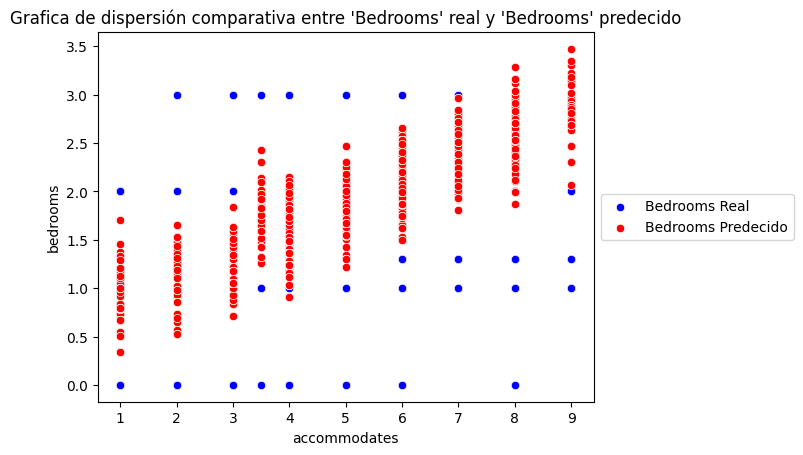

In [1947]:
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_bedrooms_multiple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_bedrooms_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Bedrooms' real y 'Bedrooms' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Bedrooms Real", "Bedrooms Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1948]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_bedrooms","determinacion")] = coef_Deter
coef_Deter

0.49960128805476

In [1949]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_bedrooms","correlacion")] = coef_Correl
coef_Correl

np.float64(0.7068247930390954)

# **Variable 8: price**

**Lineal Simple**

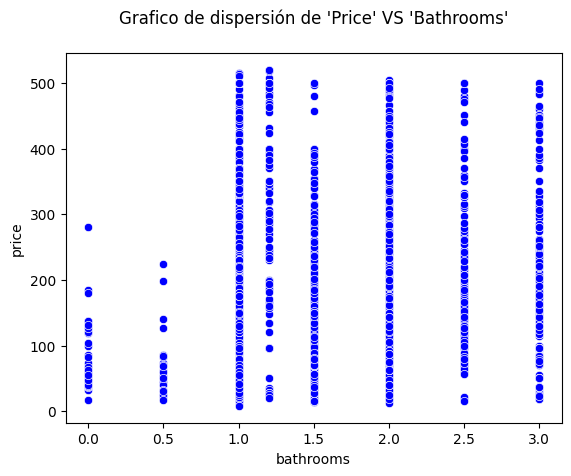

In [1950]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(price vs bathrooms)
sns.scatterplot(x='bathrooms', y='price', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Price' VS 'Bathrooms'\n")

# Mostrar la gráfica
plt.show()

In [1951]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['bathrooms']]
Var_Dep= df['price']

In [1952]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1953]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1954]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([62.38503296]),
 'rank_': 1,
 'singular_': array([46.48571998]),
 'intercept_': np.float64(23.7121773357116)}

In [1955]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.11638268551548647

In [1956]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['bathrooms']])
y_pred

array([148.48224326,  86.0972103 ,  86.0972103 , ...,  86.0972103 ,
        86.0972103 ,  86.0972103 ], shape=(14137,))

In [1957]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(45, 'Predicciones_price_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.316136,13.593356,13.614993,0.163355,0.192515,3.529641,5.212155,1.305209,1.587109,148.482243
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.310463,13.593356,13.602745,0.118844,0.140017,2.628523,2.623495,1.446410,1.238077,86.097210
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.329683,13.593356,13.665600,0.296889,0.302343,3.629765,2.423060,0.881605,0.982308,86.097210
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.290343,13.593356,13.537106,0.118844,0.155322,3.629765,3.283891,1.446410,1.361953,86.097210
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.292767,13.593356,13.706742,0.296889,0.326832,2.628523,2.623495,0.881605,0.858432,86.097210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.311337,13.593356,13.687090,0.118844,0.164505,3.629765,4.144723,1.446410,1.361953,86.097210
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.311337,4.180254,4.272778,0.296889,0.334265,2.628523,2.623495,0.881605,0.858432,86.097210
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.311337,14.769994,14.863879,0.118844,0.164505,3.629765,3.283891,1.446410,1.361953,86.097210
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.311337,5.356892,5.449567,0.207866,0.349425,3.629765,3.283891,1.164008,1.172130,86.097210


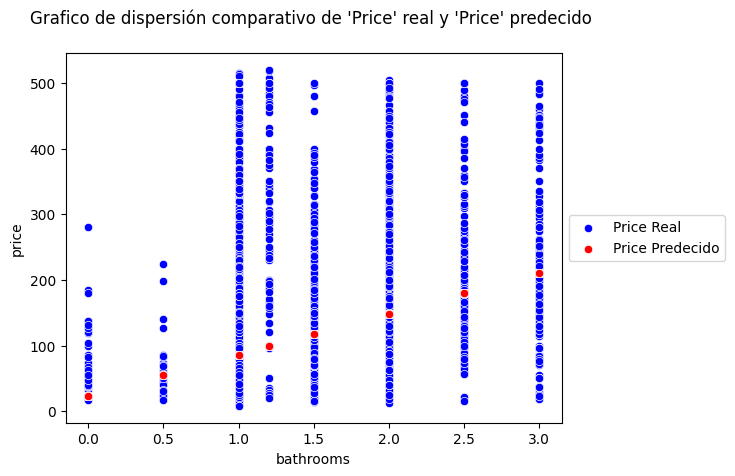

In [1958]:
sns.scatterplot(x='bathrooms', y='price', color="blue", data=df)
sns.scatterplot(x='bathrooms', y='Predicciones_price_simple', color="red", data=df)
#sns.lineplot(x='bathrooms', y='Predicciones_price_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Price' real y 'Price' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1959]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_price","determinacion")] = coef_Deter
coef_Deter

0.11638268551548647

In [1960]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_price","correlacion")] = coef_Correl
coef_Correl

np.float64(0.34114906641450227)

**Lineal Múltiple**

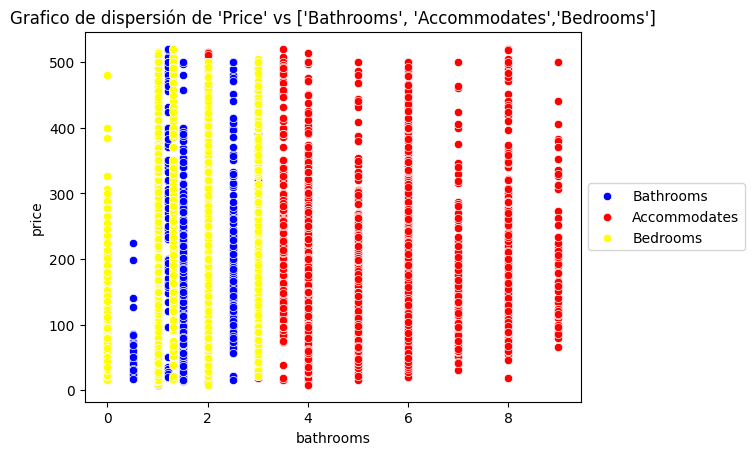

In [1961]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(price vs [bathrooms, accommodates, bedrooms])
sns.scatterplot(x='bathrooms', y='price', color="blue", data=df)
sns.scatterplot(x='accommodates', y='price', color="red", data=df)
sns.scatterplot(x='bedrooms', y='price', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Price' vs ['Bathrooms', 'Accommodates','Bedrooms']")

# Agregar la leyenda manualmente
plt.legend(labels=["Bathrooms", "Accommodates", "Bedrooms"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1962]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['bathrooms', 'accommodates', 'bedrooms']]
Var_Dep= df['price']

In [1963]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1964]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1965]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms', 'accommodates', 'bedrooms'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([46.97783797,  9.35509169,  1.64697084]),
 'rank_': 3,
 'singular_': array([190.50515564,  57.31982025,  39.84816738]),
 'intercept_': np.float64(6.23543659969981)}

In [1966]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.15345949172925732

In [1967]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['bathrooms', 'accommodates', 'bedrooms']])
y_pred

array([137.87484594,  92.28061214,  71.92345794, ...,  92.28061214,
        82.92552046,  73.57042877], shape=(14137,))

In [1968]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(46, 'Predicciones_price_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,13.593356,13.614993,0.163355,0.192515,3.529641,5.212155,1.305209,1.587109,148.482243,137.874846
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,13.593356,13.602745,0.118844,0.140017,2.628523,2.623495,1.446410,1.238077,86.097210,92.280612
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,13.593356,13.665600,0.296889,0.302343,3.629765,2.423060,0.881605,0.982308,86.097210,71.923458
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,13.593356,13.537106,0.118844,0.155322,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,13.593356,13.706742,0.296889,0.326832,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,13.593356,13.687090,0.118844,0.164505,3.629765,4.144723,1.446410,1.361953,86.097210,93.927583
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,4.180254,4.272778,0.296889,0.334265,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,14.769994,14.863879,0.118844,0.164505,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,5.356892,5.449567,0.207866,0.349425,3.629765,3.283891,1.164008,1.172130,86.097210,82.925520


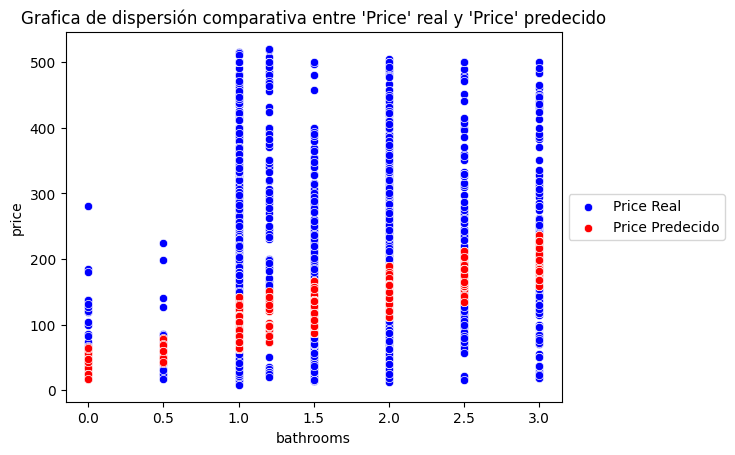

In [1969]:
sns.scatterplot(x='bathrooms', y='price', color="blue", data=df)
sns.scatterplot(x='bathrooms', y='Predicciones_price_multiple', color="red", data=df)
#sns.lineplot(x='bathrooms', y='Predicciones_price_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Price' real y 'Price' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1970]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_price","determinacion")] = coef_Deter
coef_Deter

0.15345949172925732

In [1971]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_price","correlacion")] = coef_Correl
coef_Correl

np.float64(0.3917390607652718)

# **Variable 9: review_scores_value**

**Lineal Simple**

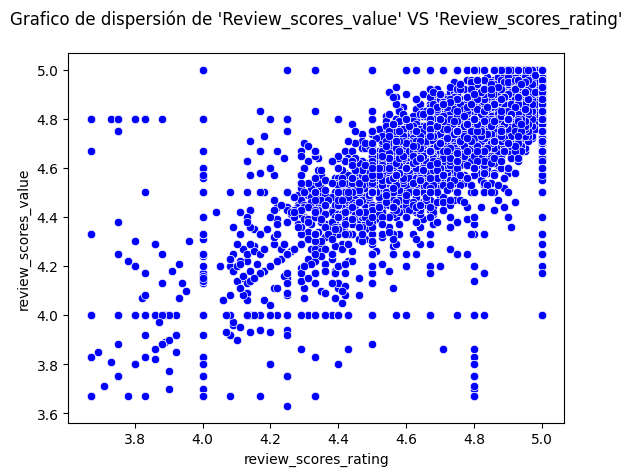

In [1972]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(review_scores_value vs review_scores_rating)
sns.scatterplot(x='review_scores_rating', y='review_scores_value', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Review_scores_value' VS 'Review_scores_rating'\n")

# Mostrar la gráfica
plt.show()

In [1973]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['review_scores_rating']]
Var_Dep= df['review_scores_value']

In [1974]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1975]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1976]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_rating'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.7063531]),
 'rank_': 1,
 'singular_': array([27.35468909]),
 'intercept_': np.float64(1.3745888199009015)}

In [1977]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.5127685416346606

In [1978]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['review_scores_rating']])
y_pred

array([4.81452844, 4.78627431, 4.80040138, ..., 4.83571903, 4.83571903,
       4.83571903], shape=(14137,))

In [1979]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(47, 'Predicciones_review_scores_value_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,13.614993,0.163355,0.192515,3.529641,5.212155,1.305209,1.587109,148.482243,137.874846,4.814528
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,13.602745,0.118844,0.140017,2.628523,2.623495,1.446410,1.238077,86.097210,92.280612,4.786274
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,13.665600,0.296889,0.302343,3.629765,2.423060,0.881605,0.982308,86.097210,71.923458,4.800401
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,13.537106,0.118844,0.155322,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.786274
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,13.706742,0.296889,0.326832,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.793338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,13.687090,0.118844,0.164505,3.629765,4.144723,1.446410,1.361953,86.097210,93.927583,4.835719
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,4.272778,0.296889,0.334265,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.835719
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,14.863879,0.118844,0.164505,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.835719
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,5.449567,0.207866,0.349425,3.629765,3.283891,1.164008,1.172130,86.097210,82.925520,4.835719


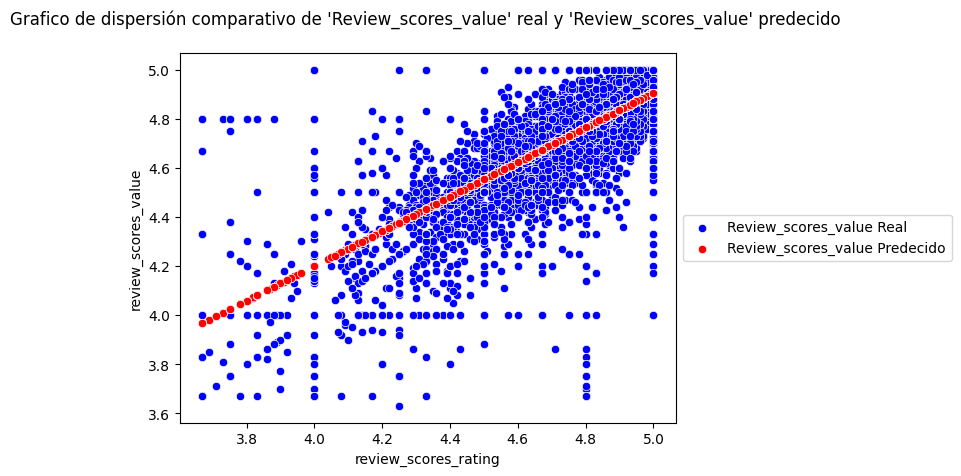

In [1980]:
sns.scatterplot(x='review_scores_rating', y='review_scores_value', color="blue", data=df)
sns.scatterplot(x='review_scores_rating', y='Predicciones_review_scores_value_simple', color="red", data=df)
#sns.lineplot(x='review_scores_rating', y='Predicciones_review_scores_value_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Review_scores_value' real y 'Review_scores_value' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Review_scores_value Real", "Review_scores_value Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1981]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_review_scores_value","determinacion")] = coef_Deter
coef_Deter

0.5127685416346606

In [1982]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_review_scores_value","correlacion")] = coef_Correl
coef_Correl

np.float64(0.716078586214293)

**Lineal Múltiple**

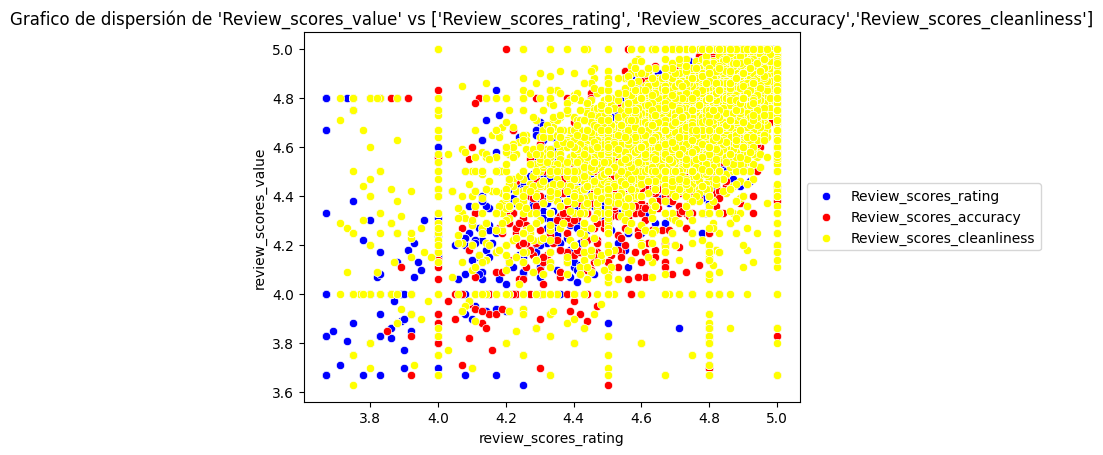

In [1983]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(review_scores_value vs [review_scores_rating, review_scores_accuracy, review_scores_cleanliness])
sns.scatterplot(x='review_scores_rating', y='review_scores_value', color="blue", data=df)
sns.scatterplot(x='review_scores_accuracy', y='review_scores_value', color="red", data=df)
sns.scatterplot(x='review_scores_cleanliness', y='review_scores_value', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Review_scores_value' vs ['Review_scores_rating', 'Review_scores_accuracy','Review_scores_cleanliness']")

# Agregar la leyenda manualmente
plt.legend(labels=["Review_scores_rating", "Review_scores_accuracy", "Review_scores_cleanliness"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [2018]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness']]
Var_Dep= df['review_scores_value']

In [2019]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [2020]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [2021]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_rating', 'review_scores_accuracy',
        'review_scores_cleanliness'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([0.47602344, 0.28521939, 0.09797545]),
 'rank_': 3,
 'singular_': array([38.76635007, 16.50613119, 13.46214116]),
 'intercept_': np.float64(0.6285076002583105)}

In [2022]:
def obtener_formula_regresion(df, variable_objetivo):
     X = df.drop(columns=[variable_objetivo])
     y = df[variable_objetivo]
     # Ajustar el modelo de regresión
     modelo = LinearRegression()
     modelo.fit(X, y)
    
     # Obtener coeficientes y término independiente (intercepto)
     coeficientes = modelo.coef_
     intercepto = modelo.intercept_
    
     # Construir la ecuación de regresión
     terminos = [f"{coef:.4f}*{col}" for coef, col in zip(coeficientes, X.columns)]
     formula = f"{variable_objetivo} = {' + '.join(terminos)} + {intercepto:.4f}"
    
     return formula

formula_regresion = obtener_formula_regresion(df, Var_Dep)
print("Fórmula de la regresión:", formula_regresion)

KeyError: '[(4.75, 4.75, 4.78, 4.82, 4.71, 4.79, 4.7, 4.94, 4.62, 4.8, 4.89, 4.8, 4.65, 4.75, 4.97, 4.9, 4.61, 4.56, 4.83, 4.65, 4.71, 4.91, 4.8, 4.71, 4.83, 4.86, 4.98, 4.74, 4.82, 4.85, 4.62, 4.6, 4.6, 4.86, 4.88, 4.5, 4.7, 4.7, 4.88, 4.91, 4.72, 4.83, 4.89, 4.88, 4.5, 4.85, 4.72, 4.86, 4.79, 4.79, 4.89, 5.0, 5.0, 4.8, 4.84, 4.75, 4.91, 4.88, 4.72, 4.92, 4.88, 4.69, 4.38, 4.7, 4.74, 4.5, 4.81, 4.67, 4.91, 4.84, 4.9, 4.76, 4.52, 4.85, 5.0, 4.53, 4.96, 4.84, 4.82, 4.62, 4.88, 4.88, 4.72, 4.82, 4.98, 4.89, 4.88, 4.92, 4.69, 4.56, 4.74, 4.81, 4.97, 4.88, 4.93, 4.81, 4.85, 4.91, 4.87, 4.87, 4.72, 4.78, 4.85, 4.7, 4.62, 4.4, 4.36, 4.8, 4.85, 4.9, 4.7, 4.75, 4.77, 4.86, 4.79, 4.67, 4.84, 4.64, 4.57, 4.93, 4.65, 4.91, 4.67, 4.8, 4.89, 4.81, 4.8, 4.88, 4.81, 3.83, 4.89, 4.94, 4.77, 4.93, 4.7, 4.81, 4.81, 4.9, 4.81, 4.59, 4.87, 4.8, 4.72, 4.77, 4.9, 4.8, 4.77, 4.93, 4.86, 4.61, 4.97, 4.93, 4.81, 4.72, 5.0, 4.64, 4.59, 4.84, 4.0, 4.58, 5.0, 4.41, 4.83, 4.64, 4.67, 5.0, 4.8, 4.67, 4.61, 4.89, 4.

In [1988]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.5536650750519095

In [1989]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness']])
y_pred

array([4.8166455 , 4.78619578, 4.82351965, ..., 4.83867717, 4.83867717,
       4.83867717], shape=(14137,))

In [1990]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(48, 'Predicciones_review_scores_value_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple,Predicciones_review_scores_value_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.163355,0.192515,3.529641,5.212155,1.305209,1.587109,148.482243,137.874846,4.814528,4.816645
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.118844,0.140017,2.628523,2.623495,1.446410,1.238077,86.097210,92.280612,4.786274,4.786196
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.296889,0.302343,3.629765,2.423060,0.881605,0.982308,86.097210,71.923458,4.800401,4.823520
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.118844,0.155322,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.786274,4.826301
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.296889,0.326832,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.793338,4.810290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.118844,0.164505,3.629765,4.144723,1.446410,1.361953,86.097210,93.927583,4.835719,4.838677
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.296889,0.334265,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.835719,4.838677
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.118844,0.164505,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.835719,4.838677
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.207866,0.349425,3.629765,3.283891,1.164008,1.172130,86.097210,82.925520,4.835719,4.838677


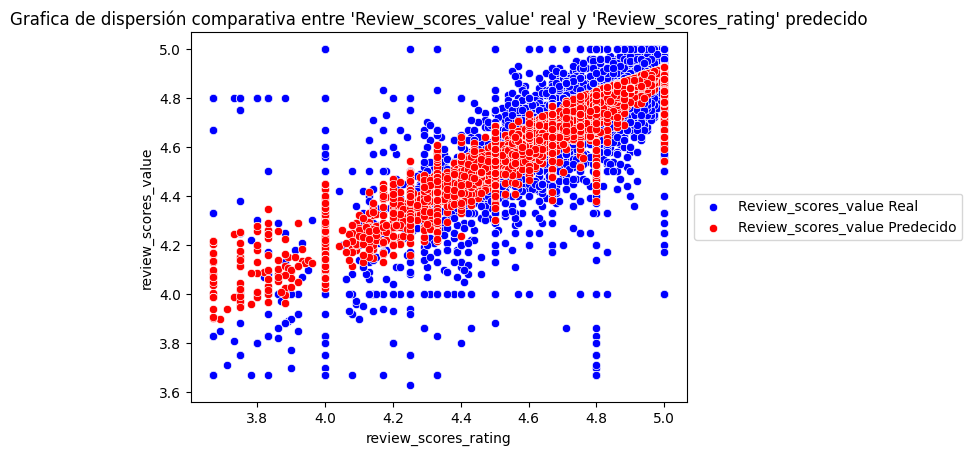

In [1991]:
sns.scatterplot(x='review_scores_rating', y='review_scores_value', color="blue", data=df)
sns.scatterplot(x='review_scores_rating', y='Predicciones_review_scores_value_multiple', color="red", data=df)
#sns.lineplot(x='review_scores_rating', y='Predicciones_review_scores_value_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Review_scores_value' real y 'Review_scores_rating' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Review_scores_value Real", "Review_scores_value Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [1992]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_review_scores_value","determinacion")] = coef_Deter
coef_Deter

0.5536650750519095

In [1993]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_review_scores_value","correlacion")] = coef_Correl
coef_Correl

np.float64(0.7440867389302873)

# **Variable 10: reviews_per_month**

**Lineal Simple**

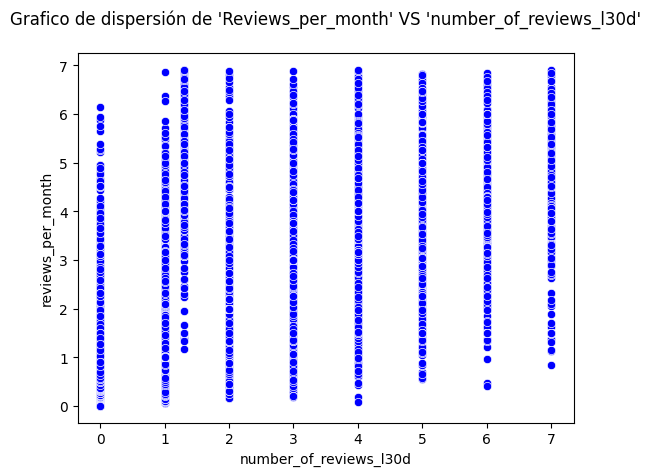

In [1994]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(reviews_per_month vs number_of_reviews_l30d)
sns.scatterplot(x='number_of_reviews_l30d', y='reviews_per_month', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Reviews_per_month' VS 'number_of_reviews_l30d'\n")

# Mostrar la gráfica
plt.show()

In [1995]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['number_of_reviews_l30d']]
Var_Dep= df['reviews_per_month']

In [1996]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [1997]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [1998]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['number_of_reviews_l30d'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.63922988]),
 'rank_': 1,
 'singular_': array([210.01334107]),
 'intercept_': np.float64(0.6722598784078638)}

In [1999]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.5210473686283581

In [2000]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['number_of_reviews_l30d']])
y_pred

array([0.67225988, 0.67225988, 0.67225988, ..., 0.67225988, 0.67225988,
       0.67225988], shape=(14137,))

In [2001]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(49, 'Predicciones_reviews_per_month_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple,Predicciones_review_scores_value_multiple,Predicciones_reviews_per_month_simple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,0.192515,3.529641,5.212155,1.305209,1.587109,148.482243,137.874846,4.814528,4.816645,0.67226
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.140017,2.628523,2.623495,1.446410,1.238077,86.097210,92.280612,4.786274,4.786196,0.67226
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,0.302343,3.629765,2.423060,0.881605,0.982308,86.097210,71.923458,4.800401,4.823520,0.67226
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,0.155322,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.786274,4.826301,0.67226
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,0.326832,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.793338,4.810290,0.67226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,0.164505,3.629765,4.144723,1.446410,1.361953,86.097210,93.927583,4.835719,4.838677,0.67226
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,0.334265,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.835719,4.838677,0.67226
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,0.164505,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.835719,4.838677,0.67226
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,0.349425,3.629765,3.283891,1.164008,1.172130,86.097210,82.925520,4.835719,4.838677,0.67226


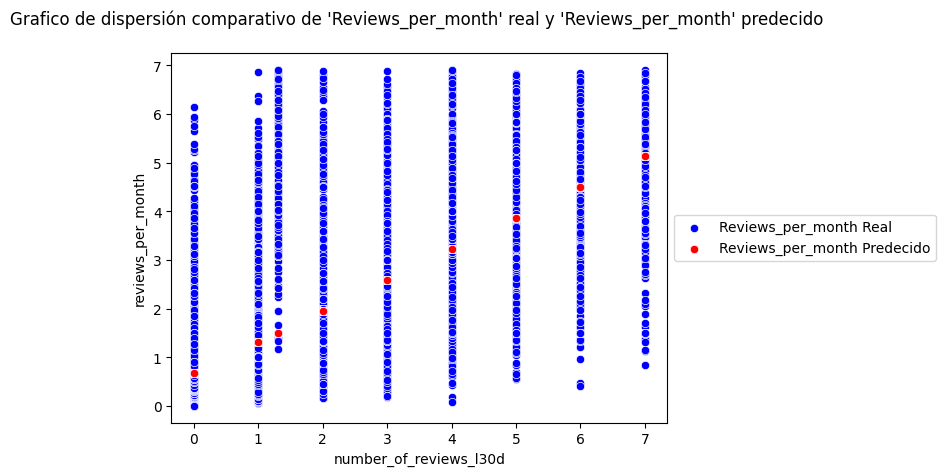

In [2002]:
sns.scatterplot(x='number_of_reviews_l30d', y='reviews_per_month', color="blue", data=df)
sns.scatterplot(x='number_of_reviews_l30d', y='Predicciones_reviews_per_month_simple', color="red", data=df)
#sns.lineplot(x='number_of_reviews_l30d', y='Predicciones_reviews_per_month_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Reviews_per_month' real y 'Reviews_per_month' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month Real", "Reviews_per_month Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [2003]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_reviews_per_month","determinacion")] = coef_Deter
coef_Deter

0.5210473686283581

In [2004]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_reviews_per_month","correlacion")] = coef_Correl
coef_Correl

np.float64(0.7218361092577442)

**Lineal Múltiple**

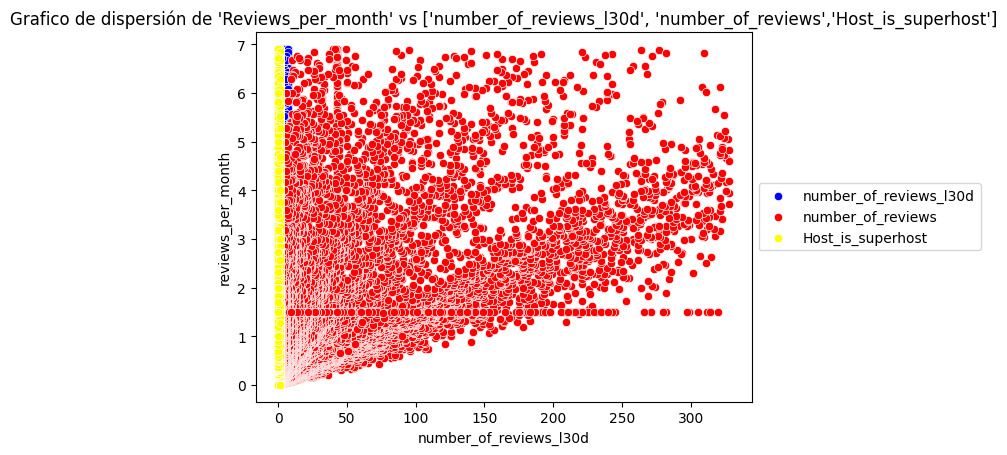

In [2005]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(reviews_per_month vs [number_of_reviews_l30d, number_of_reviews, host_is_superhost])
sns.scatterplot(x='number_of_reviews_l30d', y='reviews_per_month', color="blue", data=df)
sns.scatterplot(x='number_of_reviews', y='reviews_per_month', color="red", data=df)
sns.scatterplot(x='host_is_superhost', y='reviews_per_month', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Reviews_per_month' vs ['number_of_reviews_l30d', 'number_of_reviews','Host_is_superhost']")

# Agregar la leyenda manualmente
plt.legend(labels=["number_of_reviews_l30d", "number_of_reviews", "Host_is_superhost"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [2006]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['number_of_reviews_l30d', 'number_of_reviews', 'host_is_superhost']]
Var_Dep= df['reviews_per_month']

In [2007]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [2008]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [2009]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['number_of_reviews_l30d', 'number_of_reviews', 'host_is_superhost'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([0.52515717, 0.0064132 , 0.1935553 ]),
 'rank_': 3,
 'singular_': array([7659.95572864,  189.70012296,   55.59466426]),
 'intercept_': np.float64(0.465465441233903)}

In [2010]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.5846033680121714

In [2011]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['number_of_reviews_l30d', 'number_of_reviews', 'host_is_superhost']])
y_pred

array([0.99892018, 1.1849029 , 1.34523282, ..., 0.46546544, 0.65902075,
       0.65902075], shape=(14137,))

In [2012]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(50, 'Predicciones_reviews_per_month_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple,Predicciones_review_scores_value_multiple,Predicciones_reviews_per_month_simple,Predicciones_reviews_per_month_multiple
0,1,0,10595,1.0,1.00,10.0,12.0,37.988630,23.765270,3.5,...,3.529641,5.212155,1.305209,1.587109,148.482243,137.874846,4.814528,4.816645,0.67226,0.998920
1,1,0,10990,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,2.628523,2.623495,1.446410,1.238077,86.097210,92.280612,4.786274,4.786196,0.67226,1.184903
2,1,0,10993,1.0,1.00,10.0,12.0,37.988880,23.764730,2.0,...,3.629765,2.423060,0.881605,0.982308,86.097210,71.923458,4.800401,4.823520,0.67226,1.345233
3,1,0,10995,1.0,1.00,10.0,12.0,37.989030,23.764480,4.0,...,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.786274,4.826301,0.67226,0.889896
4,1,0,27262,1.0,1.00,10.0,12.0,37.989240,23.765000,2.0,...,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.793338,4.810290,0.67226,0.819351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14132,0,0,1249944747704827637,1.0,1.00,10.0,10.0,37.993366,23.732735,4.0,...,3.629765,4.144723,1.446410,1.361953,86.097210,93.927583,4.835719,4.838677,0.67226,0.465465
14133,0,0,1250012048760328092,1.0,1.00,2.0,4.0,37.963710,23.719070,2.0,...,2.628523,2.623495,0.881605,0.858432,86.097210,73.570429,4.835719,4.838677,0.67226,0.465465
14134,0,0,1250050091910224971,1.0,1.00,11.0,11.0,37.963669,23.747608,4.0,...,3.629765,3.283891,1.446410,1.361953,86.097210,92.280612,4.835719,4.838677,0.67226,0.465465
14135,1,0,1250102024274955611,1.0,0.88,3.0,4.0,37.987630,23.725520,3.0,...,3.629765,3.283891,1.164008,1.172130,86.097210,82.925520,4.835719,4.838677,0.67226,0.659021


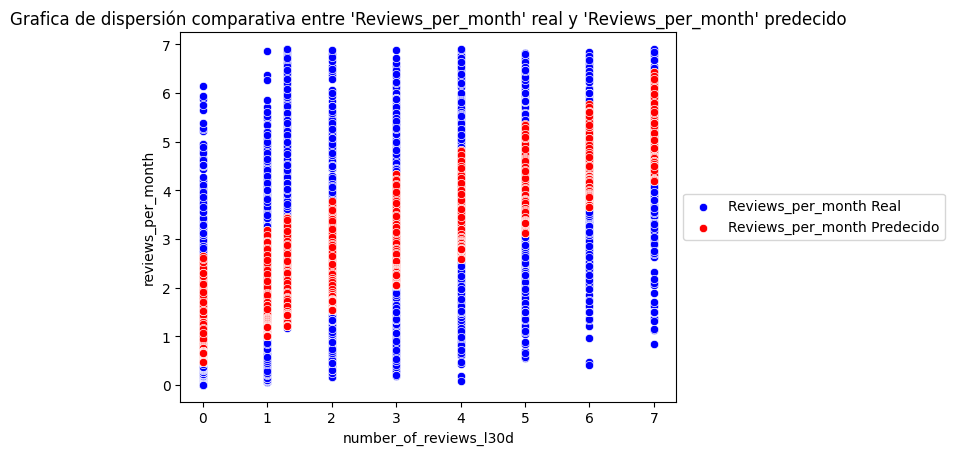

In [2013]:
sns.scatterplot(x='number_of_reviews_l30d', y='reviews_per_month', color="blue", data=df)
sns.scatterplot(x='number_of_reviews_l30d', y='Predicciones_reviews_per_month_multiple', color="red", data=df)
#sns.lineplot(x='number_of_reviews_l30d', y='Predicciones_reviews_per_month_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Reviews_per_month' real y 'Reviews_per_month' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month Real", "Reviews_per_month Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [2014]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_reviews_per_month","determinacion")] = coef_Deter
coef_Deter

0.5846033680121714

In [2015]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_reviews_per_month","correlacion")] = coef_Correl
coef_Correl

np.float64(0.76459359663299)

# Tabla de coeficientes de determinación y correlación

In [2016]:
filas = []
for (modelo, prediccion, tipo), valor in resultados.items():
    filas.append({"Modelo": modelo, "Predicción": prediccion, "Tipo": tipo, "Valor": valor})

# Crear DataFrame
df_res = pd.DataFrame(filas)

# Mostrar la tabla con formato pivotado
df_pivot = df_res.pivot(index=["Modelo", "Predicción"], columns="Tipo", values="Valor")
df_pivot

Tipo                                                  correlacion  \
Modelo          Predicción                                          
Lineal Multiple Prediccion_accommodates                  0.766591   
                Prediccion_bedrooms                      0.706825   
                Prediccion_host_acceptance_rate          0.189962   
                Prediccion_host_is_superhost             0.353301   
                Prediccion_host_total_listings_count     0.874528   
                Prediccion_id                            0.598821   
                Prediccion_price                         0.391739   
                Prediccion_review_scores_value           0.744087   
                Prediccion_reviews_per_month             0.764594   
                Prediccion_room_type                     0.304335   
Lineal Simple   Prediccion_accommodates                  0.693780   
                Prediccion_bedrooms                      0.662498   
                Prediccion_host_acceptance_rate          0.145074   
                Prediccion_host_is_superhost             0.261953   
                Prediccion_host_total_listings_count     0.874521   
                Prediccion_id                            0.500516   
                Prediccion_price                         0.341149   
                Prediccion_review_scores_value           0.716079   
                Prediccion_reviews_per_month             0.721836   
                Prediccion_room_type                     0.248443   

Tipo                                                  determinacion  
Modelo          Predicción                                           
Lineal Multiple Prediccion_accommodates                    0.587661  
                Prediccion_bedrooms                        0.499601  
                Prediccion_host_acceptance_rate            0.036086  
                Prediccion_host_is_superhost               0.124822  
                Prediccion_host_total_listings_count       0.764799  
                Prediccion_id                              0.358587  
                Prediccion_price                           0.153459  
                Prediccion_review_scores_value             0.553665  
                Prediccion_reviews_per_month               0.584603  
                Prediccion_room_type                       0.092620  
Lineal Simple   Prediccion_accommodates                    0.481330  
                Prediccion_bedrooms                        0.438904  
                Prediccion_host_acceptance_rate            0.021046  
                Prediccion_host_is_superhost               0.068620  
                Prediccion_host_total_listings_count       0.764786  
                Prediccion_id                              0.250517  
                Prediccion_price                           0.116383  
                Prediccion_review_scores_value             0.512769  
                Prediccion_reviews_per_month               0.521047  
                Prediccion_room_type                       0.061724

In [2017]:
def mostrarTabla():
    print(f"Tabla para la Predicción: {comparacion}")
    df_res_pivot

# Filtrar las comparaciones únicas (asumimos que tienes 7 comparaciones distintas)
comparaciones_unicas = df_res['Predicción'].unique()

# Crear las 7 tablas, una por cada Predicción
for comparacion in comparaciones_unicas:
    # Filtrar por la Predicción
    df_prediccion = df_res[df_res['Predicción'] == comparacion]
    
    # Pivotar la tabla para comparar los 4 datasets en cada tipo
    df_res_pivot = df_prediccion.pivot(index="Modelo", columns="Tipo", values="Valor")
    
    # Mostrar la tabla pivotada
    print(f"Tabla para la Predicción: {comparacion}")
    display(df_res_pivot)

Tabla para la Predicción: Prediccion_id


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.598821,0.358587
Lineal Simple,0.500516,0.250517


Tabla para la Predicción: Prediccion_host_acceptance_rate


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.189962,0.036086
Lineal Simple,0.145074,0.021046


Tabla para la Predicción: Prediccion_host_is_superhost


...

Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.391739,0.153459
Lineal Simple,0.341149,0.116383


Tabla para la Predicción: Prediccion_review_scores_value


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.744087,0.553665
Lineal Simple,0.716079,0.512769


Tabla para la Predicción: Prediccion_reviews_per_month


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.764594,0.584603
Lineal Simple,0.721836,0.521047
